# Практическое задание №2

В файле **Worldbank.xlsx** содержаться данные Всемирного банка по разным статьям экспорта по странам за 2018 и 2019 годы.

[Источник](https://databank.worldbank.org/source/world-development-indicators)

### Описание переменных

- CountryName - Country Name
- CountryCode - Country Code
- high_income - High income countries (принимает значение 1, если страна относится к странам с высоким доходом, 0 – если не относится)
- income - Income (принимает три значения: high income, middle income, low income)
- development - Developed or developing country (принимает два значения: developing, developed)

Столбцы с данными на 2018 год:
- Agriculturalrawmaterialsexpor - Agricultural raw materials exports (% of merchandise exports)
- ArmsexportsSIPRItrendindica - Arms exports (SIPRI trend indicator values)
- Commercialserviceexportscurr - Commercial service exports (current US dollars)
- Communicationscomputeretc - Communications, computer, etc. (% of service exports, BoP)
- Exportsofgoodsandservices - Exports of goods and services (% of GDP)
- Exportsofgoodsandservicesa - Exports of goods and services (annual percent growth)
- ExportsofgoodsandservicesB - Exports of goods and services (BoP, current US dollars)
- Exportsofgoodsandservicesc - Exports of goods and services (constant 2010 US dollarc)
- Foodexportsofmerchandisee - Food exports (% of merchandise exports)
- GoodsexportsBoPcurrentUS - Goods exports (BoP, current US dollars)
- Fuelexportsofmerchandisee - Fuel exports (% of merchandise exports)
- Hightechnologyexportsofma - High-technology exports (% of manufactured exports)
- Hightechnologyexportscurrent - High-technology exports (current US dollars)
- TaxesonexportscurrentLCU - Taxes on exports (current LCU)
- Transportservicesofservice - Transport services (% of service exports, BoP)
- Travelservicesofcommercial - Travel services (% of commercial service exports)
- Travelservicesofserviceex - Travel services (% of service exports, BoP)

Столбцы с данными на 2019 год:
- Travelservicesofcommercial2019 - Travel services (% of commercial service exports)
- Agriculturalrawmaterialsexpo2019 - Agricultural raw materials exports (% of merchandise exports)
- Communicationscomputeretc2019 - Communications, computer, etc. (% of service imports, BoP)
- Transportservicesofservice2019 - Transport services (% of service exports, BoP)

Выполните, пожалуйста, следующие задания.

### 1.Проверка отличия распределения от «нормального»
Проанализируйте распределение значений любых пяти метрических переменных. Проведите тест для проверки того отличается ли распределение значений переменных от нормального распределения. Сформулируйте гипотезы и выводы по результатам анализа. Постройте гистограммы распределения с наложенной кривой нормального распределения.

In [1]:
# здесь можно написать код
import numpy as np
import pandas as pd

In [4]:
pip install openpyxl --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 KB 2.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
url = 'Worldbank.xlsx'

In [5]:
df = pd.read_excel(url)

In [6]:
df

,CountryName,CountryCode,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,...,Transportservicesofservice,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,development,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019
0,Afghanistan,AFG,17.113304,NaN,6.230657e+08,28.402324,NaN,NaN,1.611540e+09,NaN,...,24.602029,4.482772,3.793358,0,low income,developing,14.367959,NaN,6.467647,16.344074
1,Albania,ALB,0.313849,NaN,3.574339e+09,16.058391,31.684671,3.196598,4.784712e+09,4.807222e+09,...,8.443837,61.150507,60.361848,0,middle income,developing,62.216690,NaN,5.979548,7.154605
2,Algeria,DZA,NaN,NaN,NaN,NaN,25.623547,-4.300000,NaN,5.296803e+10,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
3,American Samoa,ASM,NaN,NaN,NaN,NaN,68.867925,14.325843,NaN,3.321704e+08,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
4,Andorra,AND,1.551347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developed,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developing,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,NaN,NaN,5.608593e+08,36.257881,19.865352,7.878720,2.903485e+09,2.456322e+09,...,1.625164,43.720375,40.034937,0,middle income,developing,45.238319,0.913553,10.780279,1.079660
214,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,low income,developing,NaN,0.017167,NaN,NaN
215,Zambia,ZMB,0.903647,NaN,9.532642e+08,3.739193,37.422550,NaN,9.982666e+09,NaN,...,5.641202,77.857990,77.857990,0,middle income,developing,80.805321,1.332663,9.384435,4.395867


In [7]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
from scipy.stats import norm

In [9]:
from scipy import stats
from math import sqrt
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, norm

Проверим на нормальность переменную **Agriculturalrawmaterialsexpor** (Экспорт сельскохозяйственного сырья).

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Density'>

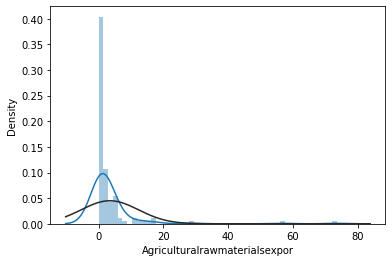

In [10]:
sns.distplot(df.Agriculturalrawmaterialsexpor.dropna(),  fit=norm)

Предварительно построим гистограмму и графически сравним распределение переменной с нормальным распределением. Распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия.

Проверка через тест. Так как выборка содержит больше 50 наблюдений, то был применен тест Колмогорова-Смирнова.

H0: Распределение значений переменной Agriculturalrawmaterialsexpor статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной Agriculturalrawmaterialsexpor статистически значимо отличается от нормального распределения.

In [11]:
stats.kstest(df['Agriculturalrawmaterialsexpor'].dropna(), 'norm', args=(df['Agriculturalrawmaterialsexpor'].dropna().mean(), df['Agriculturalrawmaterialsexpor'].dropna().std()))

KstestResult(statistic=0.347901815635626, pvalue=3.924587324163506e-14, statistic_location=0.0, statistic_sign=-1)

In [12]:
print(3.924587324163506e-14 < 0.05)

True


Таким образом, p-value < 0.05 (уровня значимости), значит гипотеза H0 отвергается, что говорит о том, что распределение переменной Agriculturalrawmaterialsexpor статистически значимо отличается от нормального распределения.

In [13]:
!pip install pingouin
import pingouin as pg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 KB 2.1 MB/s eta 0:00:00a 0:00:01


<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

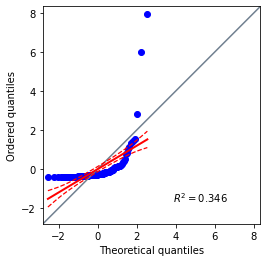

In [14]:
pg.qqplot(df['Agriculturalrawmaterialsexpor'], dist = 'norm') #график квантиль-квантиль (Q-Q plot)

По графику квантиль-квантиль дополнительно определили, соответствует ли распределение нормальному путем сравнения квантилей наших данных с квантилями нормального распределения. Точки эмпирического распределения (исследуемой переменной) не выстроены вдоль красной прямой линии. График подтверждает, что распределение рассматриваемой переменной не может быть представлено линейной функцией. Коэффициент детерминации (R^2 = 0.346) говорит о качестве соответствия линейной функции наблюдаемой переменной. Чем ближе он к 1, тем более похожи распределения. В этом случае коэффициент низкий, что дополнительно подтвержает, насколько далеко от нормального рассматриваемое распределение.

Проверим на нормальность переменную **ArmsexportsSIPRItrendindica** (Экспорт оружия).

<Axes: xlabel='ArmsexportsSIPRItrendindica', ylabel='Density'>

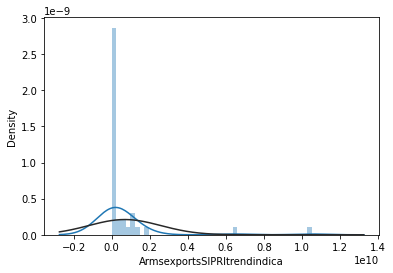

In [15]:
sns.distplot(df.ArmsexportsSIPRItrendindica.dropna(),  fit=norm)

Распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия.

In [16]:
df['ArmsexportsSIPRItrendindica'].dropna().count() #расчет количества непропущенных значений по переменной

40

In [17]:
df['ArmsexportsSIPRItrendindica'].count() #2 способ

40

В выборке по переменной ArmsexportsSIPRItrendindica 40 наблюдений.

Проверим через тест. Так как выборка содержит меньше 50 наблюдений, целесообразно применить тест Шапиро-Вилка.

H0: Распределение значений переменной ArmsexportsSIPRItrendindica статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной ArmsexportsSIPRItrendindica статистически значимо отличается от нормального распределения.

In [18]:
stats.shapiro(df['ArmsexportsSIPRItrendindica'].dropna())

ShapiroResult(statistic=0.3861824870109558, pvalue=9.669339114115605e-12)

In [19]:
print(stats.shapiro(df['ArmsexportsSIPRItrendindica'].dropna())[1] < 0.05) #сравнение p-value с уровнем значимости 5%

True


Таким образом, p-value < 0.05, значит гипотеза H0 отвергается, что говорит о том, что распределение переменной ArmsexportsSIPRItrendindica статистически значимо отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

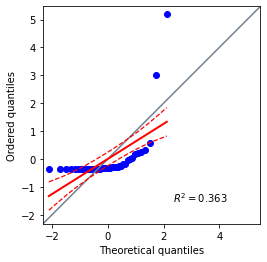

In [20]:
pg.qqplot(df['ArmsexportsSIPRItrendindica'], dist = 'norm')

Точки эмпирического распределения (исследуемой переменной) не выстроены вдоль красной прямой линии. График подтверждает, что распределение рассматриваемой переменной не может быть аппроксимировано линейной функцией. Коэффициент детерминации (R^2 = 0.363) низкий, что дополнительно подтвержает, насколько далеко от нормального рассматриваемое распределение.

Проверим на нормальность переменную **Exportsofgoodsandservicesa** (Экспорт товаров и услуг).

In [21]:
df['Exportsofgoodsandservicesa'].dropna().count() #расчет кол-ва значений в выборке по рассматриваемой переменной

151

<Axes: xlabel='Exportsofgoodsandservicesa', ylabel='Density'>

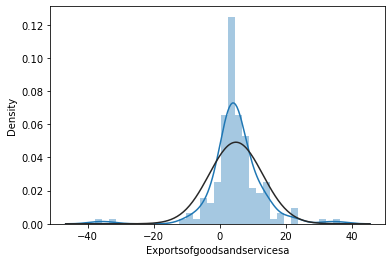

In [22]:
sns.distplot(df.Exportsofgoodsandservicesa.dropna(),  fit=norm)

По виду гистограммы можно сделать предварительный вывод, что распределение не является нормальным, хотя отсутствует явной ассиметрии в распределении принимаемых переменной значений.

Проведем тест Колмогорова-Смирнова (так как значений больше 50).

H0: Распределение значений переменной Exportsofgoodsandservicesa статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной Exportsofgoodsandservicesa статистически значимо отличается от нормального распределения.

In [23]:
stats.kstest(df['Exportsofgoodsandservicesa'].dropna(), 'norm', args=(df['Exportsofgoodsandservicesa'].dropna().mean(), df['Exportsofgoodsandservicesa'].dropna().std()))

KstestResult(statistic=0.14407431134364282, pvalue=0.003372499642179317, statistic_location=0.31839925790902157, statistic_sign=-1)

Таким образом, значение  p-value < 0.05. Следовательно, гипотеза H0 отвергается. Распределение статистически значимо отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

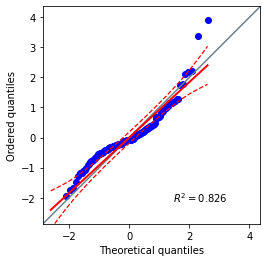

In [24]:
pg.qqplot(df['Exportsofgoodsandservicesa'], dist = 'norm')

График эмпирического распределения не выстроен вдоль прямой линии. Распределение переменной не может быть аппроксимированно линейной функцией. Тем не менее, точки уже более приближены к красной прямой линии. Коэффициент детерминации близок к 1, что означает, что данное распределение уже больше похоже на нормальное, чем рассматриваемые ранее переменные. Однако все равно не является нормальным.

Проверим на нормальность переменную **Hightechnologyexportscurrent** (Экспорт высокотехнологичной продукции).

In [25]:
df['Hightechnologyexportscurrent'].dropna().count()

109

<Axes: xlabel='Hightechnologyexportscurrent', ylabel='Density'>

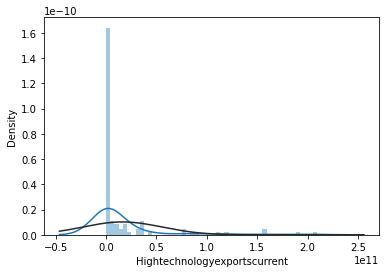

In [26]:
sns.distplot(df.Hightechnologyexportscurrent.dropna(),  fit=norm)

Распределение рассматриваемой переменной не является нормальным, наблюдается явно выраженная ассиметрия.

Проведем тест Колмогорова-Смирнова (так как значений больше 50).

H0: Распределение значений переменной Hightechnologyexportscurrent статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной Hightechnologyexportscurrent статистически значимо отличается от нормального распределения.

In [27]:
ks_tst = stats.kstest(df['Hightechnologyexportscurrent'].dropna(), 'norm', args=(df['Hightechnologyexportscurrent'].dropna().mean(), df['Hightechnologyexportscurrent'].dropna().std()))
ks_tst

KstestResult(statistic=0.33876428105147066, pvalue=1.1547889972290975e-11, statistic_location=332.0, statistic_sign=-1)

In [28]:
print(ks_tst[1]<0.05)

True


Значение p-value < 0.05. Следовательно, гипотеза H0 отвергается. Распределение статистически значимо отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

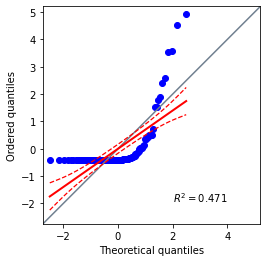

In [29]:
pg.qqplot(df['Hightechnologyexportscurrent'], dist = 'norm')

Точки эмпирического распределения (исследуемой переменной) не выстроены вдоль красной прямой линии. График подтверждает, что распределение рассматриваемой переменной не может быть аппроксимировано линейной функцией. Коэффициент детерминации (R^2 = 0.471) низкий, что дополнительно подтвержает, насколько далеко от нормального рассматриваемое распределение

Проверим на нормальность переменную **Commercialserviceexportscurr** (Экспорт коммерческих услуг).

<Axes: xlabel='Commercialserviceexportscurr', ylabel='Density'>

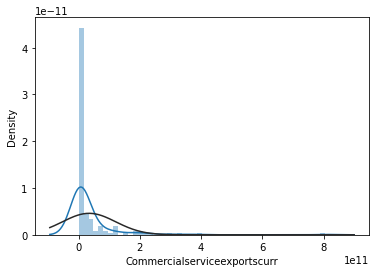

In [30]:
sns.distplot(df.Commercialserviceexportscurr.dropna(),  fit=norm)

Распределение рассматриваемой переменной по виду гистограммы распределения не является нормальным, наблюдается явно выраженная ассиметрия.

In [31]:
df['Commercialserviceexportscurr'].count()

164

Проведем тест Колмогорова-Смирнова (так как значений больше 50).

H0: Распределение значений переменной Commercialserviceexportscurr статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной Commercialserviceexportscurr статистически значимо отличается от нормального распределения.

In [32]:
stats.kstest(df['Commercialserviceexportscurr'].dropna(), 'norm', args=(df['Commercialserviceexportscurr'].dropna().mean(), df['Commercialserviceexportscurr'].dropna().std()))

KstestResult(statistic=0.34785581150990785, pvalue=3.0805246924684517e-18, statistic_location=10006298.2073266, statistic_sign=-1)

In [33]:
print(3.0805246924684517e-18 < 0.05)

True


Значение p-value < 0.05. Следовательно, гипотеза H0 отвергается. Распределение статистически значимо отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

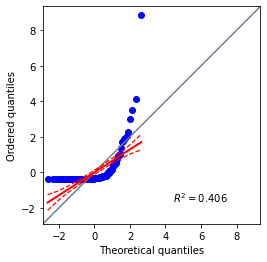

In [34]:
pg.qqplot(df['Commercialserviceexportscurr'], dist = 'norm')

Точки эмпирического распределения (исследуемой переменной) не выстроены вдоль красной прямой линии. График подтверждает, что распределение рассматриваемой переменной не может быть аппроксимировано линейной функцией. Коэффициент детерминации (R^2 = 0.406) низкий, что дополнительно подтвержает, насколько далеко от нормального рассматриваемое распределение

Таким образом, был проведен анализ 5 метрический переменных датасета путем преварительного анализа гистограмм и сравнения распределения переменных с нормальным. Были проведены тесты с целью проверки гипотез Колмогорова-Смирнова для 4 из них и тест Шапиро-Вилка - для 1. Также были проанализированы графики квантиль-квантиль для всех этих переменных. Было выявлено, что все эти переменные статистически значимо отличаются от нормального распределения.

### 2. Тест Хи-квадрат

Проведите тест Хи-квадрат не менее, чем с двумя парами переменных, для которых он применим. Можно использовать как исходные переменные, так и перекодировать их. Постройте для выбранных пар переменных таблицы сопряженности и прокомментируйте их. Сформулируйте гипотезы. Интерпретируйте результаты анализа. Обоснуйте свои выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.


Проверка, где можно использовать тест Хи-квадрат.

В теории тест Хи-квадрат проверяет на наличие взаимосвязи между категориальными переменными с не очень большим количеством категорий. В датасете 3 категориальные переменные: development, high_income и income. Но проверим на практике, с какими переменными можно использовать Хи-квадрат тест.

**Переменные ArmsexportsSIPRItrendindica и income**.

Сейчас рассматриваем метрическую и категориальную переменные, чтобы увидеть, что в этом случае тест Хи-квадрат применить нельзя.

In [35]:
aex_in = pd.crosstab(df['ArmsexportsSIPRItrendindica'], df['income'])
aex_in

income,high income,middle income
ArmsexportsSIPRItrendindica,,
0.000000e+00,1,0
1.000000e+06,0,1
2.000000e+06,0,2
3.000000e+06,3,0
5.000000e+06,1,0
6.000000e+06,1,0
7.000000e+06,0,1
1.200000e+07,1,0
1.500000e+07,0,1


Уже заметно, что в таблице сопряженности мало частот в каждой ячейке. Но все равно проведем тест Хи-квадрат.

Гипотезы:

H0: отсутствует взаимосвязь между объемами экспорта оружия и уровнем дохода страны.

H1: существует взаимосвязь между объемами экспорта оружия и уровнем дохода страны.

In [36]:
stats.chi2_contingency(aex_in)

Chi2ContingencyResult(statistic=40.0, pvalue=0.2577813812531309, dof=35, expected_freq=array([[0.675, 0.325],
       [0.675, 0.325],
       [1.35 , 0.65 ],
       [2.025, 0.975],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [1.35 , 0.65 ],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325],
       [0.675, 0.325]]))

Таким образом, стиатистический тест Хи-квадрат не может быть применен в данном случае. Ожидаемые частоты (записанные в array) имеют значения меньше 5. Поэтому для того, чтобы сделать вывод о наличии (или отсутствии) взаимосвязи между данными переменными, необходимо использовать другой тест.

**Уровень развития страны (Development) и Уровень дохода (Income)**

Гипотезы:

H0: отсутствует взаимосвязь между уровнем развития страны и уровнем дохода.

H1: существует взаимосвязь между уровнем развития страны и уровнем дохода.

In [37]:
#таблица сопряженности, в ячейках - частоты
dvp_income = pd.crosstab(df['development'], df['income'])
dvp_income

income,high income,low income,middle income
development,,,
developed,46,0,1
developing,36,29,105


Данные дают понимание о частоте, с которой рассматриваемые категории стран встречаются в выборке. Таким образом, в датасете 105 развивающихся стран со средним уровнем дохода. Их подавляющее количество.  Только 1 страна со средним уровнем дохода, которая является развивающей экономикой. Примерно равное количество развивающихся и развитых стран с высоким уровнем дохода (но больше развитых).

In [38]:
pd.crosstab(df['development'], df['income'], margins=True, margins_name='Total', normalize='columns').round(3) #в ячейках - доли, по столбцам в сумме - 1

income,high income,low income,middle income,Total
development,,,,
developed,0.561,0.0,0.009,0.217
developing,0.439,1.0,0.991,0.783


Из таблицы сопряженности можно сделать вывод о доле стран с разным уровнем развития в разных категориях по уровню дохода. Можно отметить, что 56% стран с высоким уровнем дохода - развитые экономики, 43,9% - развивающиеся страны. Среди бедных стран только развивающиеся экономики. Подавляющее большинство стран (99%) в категории со средним уровнем дохода - развивающиеся экономики. В датасете на развивающиеся страны приходится 78,3%, на развитые - 21,7%.

In [39]:
pd.crosstab(df['income'], df['development'], margins=True, margins_name='Total',normalize='columns').round(3)

development,developed,developing,Total
income,,,
high income,0.979,0.212,0.378
low income,0.000,0.171,0.134
middle income,0.021,0.618,0.488


Из данной таблицы можно сделать вывод о доле стран по уровню развития в каждой категории по уровню дохода. 97,9% развитых стран имеют высокий уровень дохода. В датасете 48,8% - страны со средним доходом (большинство), 37,8% - с высоким доходом, 13,4% - с низким. Нет развитых стран с низким уровнем дохода. Среди развивающихся экономик 61,8% - страны со средним доходом, а 21,2% приходится на страны с высоким уровнем благосостояния.

<Axes: xlabel='development'>

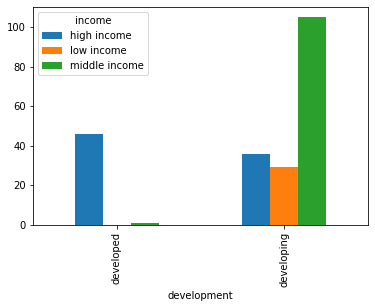

In [40]:
df.groupby('development')['income'].value_counts().unstack().plot(kind='bar') #по оси ординат отражены частоты

<Axes: xlabel='development'>

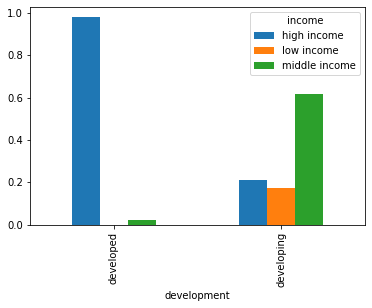

In [41]:
df.groupby('development')['income'].value_counts(normalize=True).unstack().plot(kind='bar') #по оси ординат - доли

<Axes: xlabel='income'>

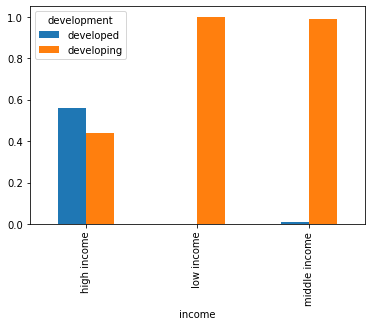

In [42]:
df.groupby('income')['development'].value_counts(normalize=True).unstack().plot(kind='bar')

Столбчатые диаграммы фактически наглядно иллюстрируют выводы, которые были сделаны на основе анализа таблиц сопряженности. Из первых двух диаграмм видно, что среди развивающихся стран наибольшая доля приходится на государства со средним уровнем дохода. В категории развитых стран доминирующая доля приходится на богатые экономики. Также видно, что доля (и частота) развивающихся стран в выборке выше.

Третья диаграмма дает понимание, что в категории стран с самым высоким благосостоянием представлены как развитые, так и развивающиеся (почти в равной доле, но с превышением доли развитых).

In [43]:
from scipy import stats

In [44]:
stats.chi2_contingency(dvp_income)

Chi2ContingencyResult(statistic=92.14232018624294, pvalue=9.807298562412372e-21, dof=2, expected_freq=array([[17.76036866,  6.28110599, 22.95852535],
       [64.23963134, 22.71889401, 83.04147465]]))

Ожидаемые частоты (array) содержат все значения, выше 5, значит тест Хи-квадрат применим для этих переменных.



In [45]:
print ('p-value = ', stats.chi2_contingency(dvp_income)[1], ',', 'chi2 = ', stats.chi2_contingency(dvp_income)[0])

p-value =  9.807298562412372e-21 , chi2 =  92.14232018624294


In [46]:
print (stats.chi2_contingency(dvp_income)[1] < 0.05)

True


Таким образом, p-value < 0.05 (принятого в курсе уровня значимости 5%). Нулевая гипотеза отвергается, принимается гипотеза H1. Значит, между уровнем развития страны и уровнем дохода существует взаимосвязь.

**Уровень развития страны (Development) и Высокий уровень дохода (high_income)**

Гипотезы:

H0: отсутствует взаимосвязь между уровнем развития страны и высоким уровнем дохода.

H1: существует взаимосвязь между уровнем развития страны и высоким уровнем дохода.

In [47]:
dvp_hinc = pd.crosstab(df['development'], df['high_income'])
dvp_hinc

high_income,0,1
development,,
developed,1,46
developing,134,36


На основе таблицы можно определить частоту, с которой в датасете встречаются страны каждой категории. Подавляющее число стран - развивающиеся, не имеющие высокий доход (134). Только 1 развитая, не принадлежащая при этом к числу богатых экономик.  Вторая по частотности группа - страны с высоким благосостоянием и развитой экономикой (46). Третья группа по количеству - развивающиеся, богатые экономики (36 случаев).

In [48]:
pd.crosstab(df['development'], df['high_income'], margins=True, margins_name='Total', normalize='columns').round(3) #в ячейках - доли, по столбцам в сумме - 1

high_income,0,1,Total
development,,,
developed,0.007,0.561,0.217
developing,0.993,0.439,0.783


Данная таблица показывает долю государств с высоким и невысоким доходом в зависимости от уровня развития. Из таблицы видно, что 99,3% не богатых стран являются развивающимися. В группе богатых экономик 56,1% приходится на развитые и 43,9% на развивающиеся страны.

In [49]:
pd.crosstab(df['high_income'], df['development'], margins=True, margins_name='Total', normalize='columns').round(3)

development,developed,developing,Total
high_income,,,
0,0.021,0.788,0.622
1,0.979,0.212,0.378


Данная таблица показывает доли развитых и развивающихся государств в зависимости от величины дохода. 97,9% развитых экономик - страна с высоким доходом. 78,8% развивающихся стран - государства, не располагающие высоким доходом.  

<Axes: xlabel='development'>

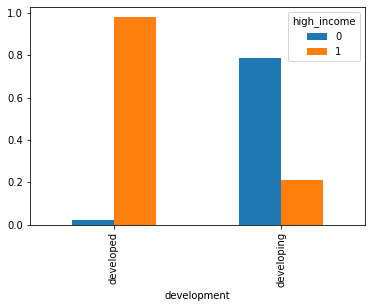

In [50]:
df.groupby('development')['high_income'].value_counts(normalize=True).unstack().plot(kind='bar') #длина столбцов - доли

<Axes: xlabel='development'>

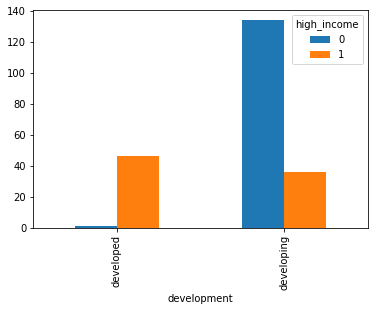

In [51]:
df.groupby('development')['high_income'].value_counts().unstack().plot(kind='bar') #длина столбцов отражает частоты

Подобно анализу, проведенному с другой парой переменных выше, были построены столбчатые диаграммы, которые иллюстрируют выводы, уже сформулированные на основе данных таблиц сопряженности. Для данных переменных были постороены диаграммы, где длине столбцов соответствуют процент (/доля) и частоты.

На первой диаграмме рассматриваем распределение долей стран с высоким и невысоким доходом в зависимости от уровня развития. В категории развитых подавляющая доля приходится на богатые страны, а в группе развивающихся - на менее обеспеченные государства.
Из второй диаграммы видно, что в выборке чаще всего встречаются развивающиеся страны с невысоким уровнем дохода, а на втором месте по численности - развитые обеспеченные страны.

In [52]:
stats.chi2_contingency(dvp_hinc)

Chi2ContingencyResult(statistic=88.89680884133621, pvalue=4.159538519406816e-21, dof=1, expected_freq=array([[ 29.23963134,  17.76036866],
       [105.76036866,  64.23963134]]))

In [53]:
print (stats.chi2_contingency(dvp_hinc)[1] < 0.05)

True


Ожидаемые частоты (array) выше 5, поэтому тест Хи-квадрат может быть использован для проверки взаимосвязи между переменными.

Значение p-value ниже 0,05, и значит гипотеза Н0 отвергается в пользу Н1. Можно заключить, что между переменными есть взаимосвязь.

### 3. Парная корреляция

Проведите корреляционный анализ переменных (нужно рассмотреть не менее трёх разных пар переменных). Обоснуйте выбор рассчитываемых коэффициентов корреляции. Сформулируйте гипотезы. Визуализируйте наблюдаемые тенденции на подходящих графиках. Интерпретируйте результаты анализа (статистическая значимость, сила и направление взаимосвязи). Заполните таблицу (не менее 3 записей).

| Анализируемые пары переменных | Выбранный коэффициент корреляции (обоснование выбора) | Гипотезы | Сила взаимосвязи | Направление взаимосвязи | Статистическая значимость взаимосвязи |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |

1. **Анализируемые пары переменных**: GoodsexportsBoPcurrentUS и ExportsofgoodsandservicesB; **Выбранный коэффициент корреляции:** коэффициент Спирмена (данные не имеют нормального распределения + данные уникальные, ранги несвязаны); **Гипотезы:** H0 = указанные показатели не имеют корреляции H1 = указанные показатели имеют корреляцию; Статистическая значимость (p-value) = 1.6190280032863501×10^−114. Направление взаимосвязи - прямая, полоительная корреляция, сила взаимосвязи - очень сильная корреляция (0,9 < r < 1)

2. **Анализируемые пары переменных:** Transportservicesofservice и Travelservicesofserviceex; **Выбранный коэффициент корреляции:** коэффициент Спирмена (имеем дело с уникальными значениями переменной, где ранги несвязанные.); **Гипотезы:** H0 = указанные показатели не имеют корреляции H1 = указанные показатели имеют корреляцию; **Статистическая значимость** (p-value) = 8.842307562598063e-06. **Направление взаимосвязи** - обратная, отрицательная корреляция, сила взаимосвязи - слабая корреляция.

3. **Анализируемые пары переменных:** Agriculturalrawmaterialsexpor и Foodexportsofmerchandisee; **Выбранный коэффициент корреляции:** коэффициент Спирмена (обе переменные не имеют нормального распределения); **Гипотезы:** H0 = указанные показатели не имеют корреляции H1 = указанные показатели имеют корреляцию; **Статистическая значимость** (p-value) = 0.01165581624593378. **Направление взаимосвязи** - прямая, положительная корреляция, сила взаимосвязи - слабая корреляция (0,2 < r < 0,5).

4. **Анализируемые пары переменных:** income и Hightechnologyexportscurrent; **Выбранный коэффициент корреляции:** коэффициент Кендалла (одна переменная не имеет нормального распределения, вторая - категориальная, при ранжировании много связанных рангов); **Гипотезы:** H0 = указанные показатели не имеют корреляции H1 = указанные показатели имеют корреляцию; **Сила взаимосвязи:** коэффициент равен 0.33, слабая корреляция; **Направление взаимосвязи:** прямая взаимосвязь (коэффициент корреляции > 0); **Статистическая значимость взаимосвязи:** p-value < 0.05, H1 принимается.

Корреляционный анализ включает в себя 4 этапа:
1. Построение диаграмм(ы) рассеяния
2. Выбор подходящего коэффициента корреляции (Пирсон/Спирмен/Кендалл)
3. Расчет p-value
4. Интерпретация статистического значения


Подготовка в анализу:

В качестве первой пары были выбраны "ExportsofgoodsandservicesB" (Экспорт товаров и услуг (платежный баланс, текущие доллары США)) и "GoodsexportsBoPcurrentUS" (Экспорт товаров (платежный баланс, текущие доллары США)). Выбор именно этих показателей обоснован, преимущественно, одинаковой (то есть, сравнимой) размерностью. Дело в том, что большинство данных в данной таблице измеряются в разных величинах и/или берутся от разных величин (в случае процентов). Таким образом, выбор необходимых показателей сводится к анализу размерности и надежды, что анализ таких сущностей будет иметь экономический смысл. В данном конкретном случае, экономический смысл будет вполне формальный, поскольку очевидно, что экспорт товаров это буквально часть экспортатоваров и услуг.

Гипотезы:
H0 = указанные показатели не имеют корреляции
H1 = указанные показатели имеют корреляцию

<Axes: xlabel='ExportsofgoodsandservicesB', ylabel='GoodsexportsBoPcurrentUS'>

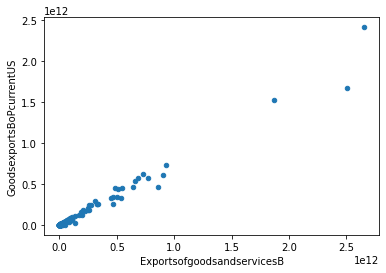

In [54]:
df.plot('ExportsofgoodsandservicesB', 'GoodsexportsBoPcurrentUS', kind='scatter')

Как и говорилось ранее, между параметрами сразу заметна очень сильная связь. Виден четкий тренд. Между параметрами есть положительная корреляцию.

In [55]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [56]:
from scipy.stats import norm

<Axes: xlabel='ExportsofgoodsandservicesB', ylabel='Density'>

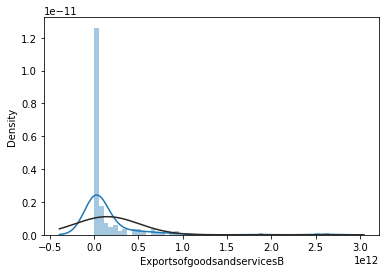

In [57]:
sns.distplot(df.ExportsofgoodsandservicesB.dropna(),  fit=norm)

Перед тем как выбрать нужный коэффициент корреляции нужно построиить гистограмму и сравнить распределение переменной с нормальным распределением. Распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия.

<Axes: xlabel='GoodsexportsBoPcurrentUS', ylabel='Density'>

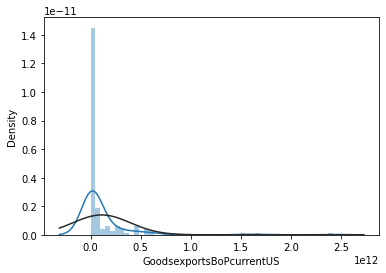

In [58]:
sns.distplot(df.GoodsexportsBoPcurrentUS.dropna(),  fit=norm)

Перед тем как выбрать нужный коэффициент корреляции нужно построиить гистограмму и сравнить распределение переменной с нормальным распределением. Распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия.

Данные по обеим переменным не имеют нормального распределения, поэтому коэффициент Пирсона не подходит. Между Спирменом и Кендаллом целесообразнее использовать коэффициент Спирмена, потому что мы имеем дело с уникальными значениями переменной, где ранги несвязанные.


In [59]:
from scipy import stats

In [60]:
from scipy.stats import pointbiserialr, norm

In [61]:
df[['ExportsofgoodsandservicesB','GoodsexportsBoPcurrentUS']].corr('spearman')

,ExportsofgoodsandservicesB,GoodsexportsBoPcurrentUS
ExportsofgoodsandservicesB,1.000000,0.979833
GoodsexportsBoPcurrentUS,0.979833,1.000000


Теория о том, что данные представляют практически один и тот же экономический смысл подтверждается. Корреляция близка к 1.

In [62]:
df_cln = df.dropna(subset=['ExportsofgoodsandservicesB', 'GoodsexportsBoPcurrentUS'])

<Axes: xlabel='ExportsofgoodsandservicesB', ylabel='GoodsexportsBoPcurrentUS'>

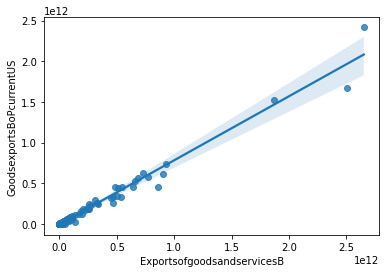

In [63]:
sns.regplot(data = df_cln, x = 'ExportsofgoodsandservicesB', y = 'GoodsexportsBoPcurrentUS') #диаграмма рассеивания с наложением модели линейной функции

In [64]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df_cln['ExportsofgoodsandservicesB'], df_cln['GoodsexportsBoPcurrentUS'])
print(f"Коэффициент корреляции Спирмена: {corr}, p-value: {p_value}")

Коэффициент корреляции Спирмена: 0.9798327431127072, p-value: 1.6190280032863501e-114


p-value = 1.6190280032863501×10^−114 < 0,05 (уровень ззначимости). P-value значительно меньше уровня значимости 5%. Следовательно, Н0 отвергается, а значит, между переменными есть корреляция (ярковыраженная).

**Переменные Transportservicesofservice и Travelservicesofserviceex**

В качестве второй пары переменных были выбраны Transportservicesofservice - Transport services (% of service exports, BoP) и
Travelservicesofserviceex - Travel services (% of service exports, BoP). Выбор именно этих переменных обоснован сопоставимой размерностью (в чисто математическом смысле) и возможной с экономической точки зрения зависимостью (в концептуальном смысле).

Гипотезы:

H0 = между переменными нет корреляции

H1 =  между переменными есть корреляция

<Axes: xlabel='Transportservicesofservice', ylabel='Travelservicesofserviceex'>

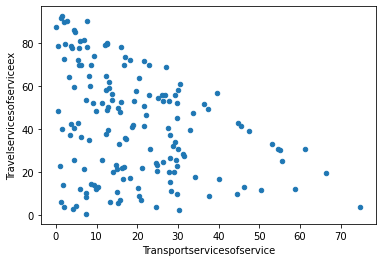

In [65]:
df.plot('Transportservicesofservice', 'Travelservicesofserviceex', kind='scatter')

Между параметрами нет линейной зависимости (совсем). Четкого тренда нет. Между параметрами корреляции нет.

Для подбора нужного коэффицента корреляции сначала нужно построить столбчатые графики с наложением колоковидной кривой, чтобы сделать вывод о наличии или отсутствии нормального распределения.

<Axes: xlabel='Transportservicesofservice', ylabel='Density'>

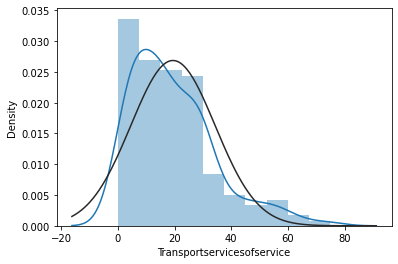

In [66]:
sns.distplot(df.Transportservicesofservice.dropna(),  fit=norm)

Распределение рассматриваемой переменной по виду гистограммы в достаточной степени приближено к нормальному. Наблюдается  небольшая ассиметрия. В задании 5 был проведен тест Колмогорова-Смирнова, по результатам которого получили, что распределение статистически значимо не отличается от нормального.

<Axes: xlabel='Travelservicesofserviceex', ylabel='Density'>

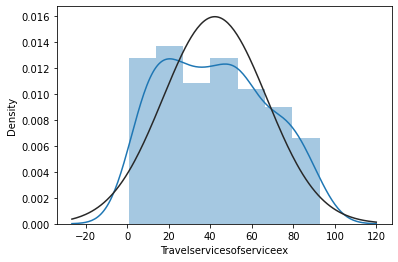

In [67]:
sns.distplot(df.Travelservicesofserviceex.dropna(),  fit=norm)

Распределение рассматриваемой переменной по виду гистограммы в достаточной степени приближено к нормальному. Наблюдается  небольшая ассиметрия. Поэтому проведем тест Колгомогорова-Смирнова, чтобы проверить распределение на соответствие нормальному.

Гипотезы:

H0: Распределение значений переменной процент туристических услуг от общего экспорта услуг статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной процент туристических услуг от общего экспорта услуг статистически значимо отличается от нормального распределения.

In [68]:
stats.kstest(df['Travelservicesofserviceex'].dropna(), 'norm', args=(df['Travelservicesofserviceex'].dropna().mean(), df['Travelservicesofserviceex'].dropna().std()))

KstestResult(statistic=0.08336118017262839, pvalue=0.2015993092471281, statistic_location=25.959672299646304, statistic_sign=1)

p-value > 0.05, гипотеза H1 отвергается, а H0 не отвергается => распределение статистически значимо не отличается от нормального.

Так как распределение обеих переменных статистически не отличается от нормального, а проценты в данном конкретном случае могут рассматриваться как количественные данные, мы будем использовать коэффициент Пирсона.

In [69]:
df_cl = df[['Transportservicesofservice', 'Travelservicesofserviceex']].dropna()

In [70]:
correlation, p_value = stats.pearsonr(
    df_cl['Transportservicesofservice'],
    df_cl['Travelservicesofserviceex']
)
print(f"Pearson correlation: {correlation}, p-value: {p_value}")

Pearson correlation: -0.3442902877153566, p-value: 8.842307562598063e-06


Корреляция между перменными отрицательная, p-value < 0,05 => H0 отвергается в пользу H1. Следовательно, между переменными есть корреляция. Наблюдается обратная взаимосвязь. С увеличением доли оказанных транспортных услуг снижается процент туристических услуг в структуре экспорта услуг.

<Axes: xlabel='Transportservicesofservice', ylabel='Travelservicesofserviceex'>

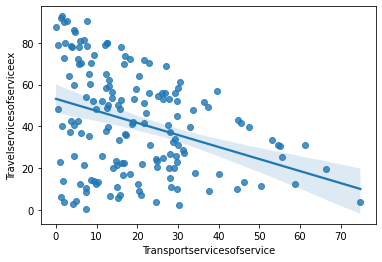

In [71]:
sns.regplot(data = df_cl, x = 'Transportservicesofservice', y = 'Travelservicesofserviceex')

**Переменные Agriculturalrawmaterialsexpor и Foodexportsofmerchandisee**

В качестве третьей переменной были выбраны Agriculturalrawmaterialsexpor - Agricultural raw materials exports (% of merchandise exports) и Foodexportsofmerchandisee - Food exports (% of merchandise exports). Выбор обусловлен одинаковой размерностью величин (в обоих случаях проценты берутся от товарного экспорта), а также возможной экономической (смысловой) связанностью.

Гипотезы:

H0 = указанные показатели не имеют корреляции

H1 = указанные показатели имеют корреляцию

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Foodexportsofmerchandisee'>

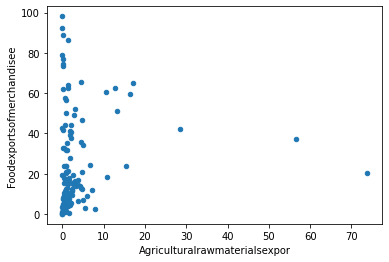

In [72]:
df.plot('Agriculturalrawmaterialsexpor', 'Foodexportsofmerchandisee', kind='scatter')

Между параметрами сразу заметна сильная связь. Виден четкий тренд, однако, присутствуют выборсы. Между параметрами есть положительная корреляцию. В чисто экономическом смысле это может означать, что экспорт сельскохозяйственного сырья может в данном конкретном случае служить основой для производства продуктов питания. Отсюда можно сделать вид, что увеличение экспорта сырья может способствовать росту экспорта готовых продуктов. Оговоримся, что это не всегда может быть так, поскольку некоторые страны могут использовать сырье для внутреннего потребления или переработки, а не для экспорта готовых продуктов. Кроме того, повторимся, что и данном случае связь является не идеально линейной, так что тут можно говорить, в лучшем случае, а довольно часто проявляющейся тенденции, но не о правиле в классическом понимании.

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Density'>

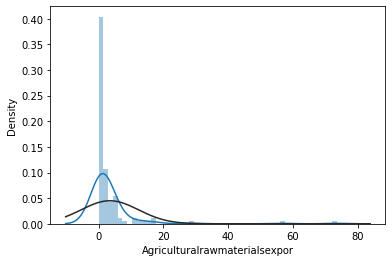

In [73]:
sns.distplot(df.Agriculturalrawmaterialsexpor.dropna(),  fit=norm)

Распределение рассматриваемой переменной не является нормальным. Наблюдается небольшая ассиметрия.

<Axes: xlabel='Foodexportsofmerchandisee', ylabel='Density'>

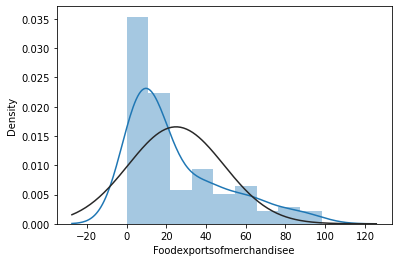

In [74]:
sns.distplot(df.Foodexportsofmerchandisee.dropna(),  fit=norm)

Распределение рассматриваемой переменной не является нормальным, хотя и в достаточной степени к нему приближено. Наблюдается небольшая ассиметрия.

Так как обе переменные не имеют нормального распределения (хоть у второй переменной оно и достаточно близко к нему) мы будем использовать коэффициент Спирмена.

In [75]:
print(df.columns)

Index(['CountryName', 'CountryCode', 'Agriculturalrawmaterialsexpor',
       'ArmsexportsSIPRItrendindica', 'Commercialserviceexportscurr',
       'Communicationscomputeretc', 'Exportsofgoodsandservices',
       'Exportsofgoodsandservicesa', 'ExportsofgoodsandservicesB',
       'Exportsofgoodsandservicesc', 'Foodexportsofmerchandisee',
       'GoodsexportsBoPcurrentUS', 'Fuelexportsofmerchandisee',
       'Hightechnologyexportsofma', 'Hightechnologyexportscurrent',
       'TaxesonexportscurrentLCU', 'Transportservicesofservice',
       'Travelservicesofcommercial', 'Travelservicesofserviceex',
       'high_income', 'income', 'development',
       'Travelservicesofcommercial2019', 'Agriculturalrawmaterialsexpo2019',
       'Communicationscomputeretc2019', 'Transportservicesofservice2019'],
      dtype='object')


In [76]:
from scipy.stats import spearmanr

In [77]:
df_dr = df.dropna(subset=['Agriculturalrawmaterialsexpor', 'Foodexportsofmerchandisee'])

In [78]:
corr, p_value = spearmanr(df_dr['Agriculturalrawmaterialsexpor'], df_dr['Foodexportsofmerchandisee'])
print(f"Коэффициент корреляции Спирмена: {corr}, p-value: {p_value}")

Коэффициент корреляции Спирмена: 0.22408098987626549, p-value: 0.011655816245933778


Корреляция между перменными положительная, p-value < 0,05 => H0 отвергается в пользу H1. Следовательно, между переменными есть корреляция. Отметим, что значение p-value незначительно меньше используемого уровня значимости, что говорит о пограничности результата.

**Переменные income и Hightechnologyexportscurrent**

<Axes: xlabel='Hightechnologyexportscurrent', ylabel='Density'>

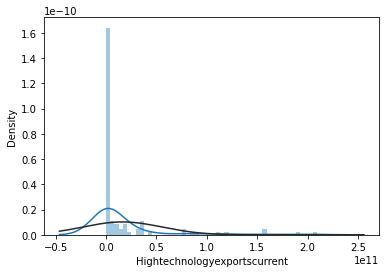

In [79]:
sns.distplot(df.Hightechnologyexportscurrent.dropna(),  fit=norm)

Переменная Hightechnologyexportscurrent - метрическая переменная. По виду построенной выше гистограммы можно сделать вывод, что распределение переменной не является нормальным, заметна явная ассиметрия. Переменная income - категориальная переменная.

Имеет смысл проверить корреляцию между данными переменными. Предполагаем, что между ними может быть положительная взаимосвязь, так как с повышением уровня дохода страна может получить доступ к высоким технологиям внутри страны, а также поставлять их на экспорт.

Для проверки корреляции перекодируем переменную income в числа для каждой категории: high income - 2, middle income - 1, low income - 0.

In [80]:
df2 = df
#перенесем все данные в другую пеменную,чтобы при перекодировке не изменился изначальный датасет
#хотя можно было создать новый столбец

In [81]:
df2

,CountryName,CountryCode,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,...,Transportservicesofservice,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,development,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019
0,Afghanistan,AFG,17.113304,NaN,6.230657e+08,28.402324,NaN,NaN,1.611540e+09,NaN,...,24.602029,4.482772,3.793358,0,low income,developing,14.367959,NaN,6.467647,16.344074
1,Albania,ALB,0.313849,NaN,3.574339e+09,16.058391,31.684671,3.196598,4.784712e+09,4.807222e+09,...,8.443837,61.150507,60.361848,0,middle income,developing,62.216690,NaN,5.979548,7.154605
2,Algeria,DZA,NaN,NaN,NaN,NaN,25.623547,-4.300000,NaN,5.296803e+10,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
3,American Samoa,ASM,NaN,NaN,NaN,NaN,68.867925,14.325843,NaN,3.321704e+08,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
4,Andorra,AND,1.551347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developed,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developing,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,NaN,NaN,5.608593e+08,36.257881,19.865352,7.878720,2.903485e+09,2.456322e+09,...,1.625164,43.720375,40.034937,0,middle income,developing,45.238319,0.913553,10.780279,1.079660
214,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,low income,developing,NaN,0.017167,NaN,NaN
215,Zambia,ZMB,0.903647,NaN,9.532642e+08,3.739193,37.422550,NaN,9.982666e+09,NaN,...,5.641202,77.857990,77.857990,0,middle income,developing,80.805321,1.332663,9.384435,4.395867


In [82]:
df2['income']=df2['income'].replace('low income', 0)
df2['income']=df2['income'].replace('middle income', 1)
df2['income']=df2['income'].replace('high income', 2)
df2['income'].value_counts()

income
1    106
2     82
0     29
Name: count, dtype: int64

Коэффициент корреляции Пирсона в этом случае не применим, так как одна переменная метрическая, не имеющая нормального распределения. Переменная income имеет порядковую шкалу. Выбирая между коэффициентами Кендалла и Спирмена, обратили внимание на то, что значения переменной income не являются уникальными, что можно понять из таблицы выше. По этой причине при ранжировании стран по данной переменной много связанных (одинаковых) рангов. Поэтому рассчитаем коэффициент Кендалла.

Гипотезы:

H0: нет взаимосвязи между уровнем доходом стран и уровнем экспорта высокотехнологичной продукции

H1: существует взаимосвязь между уровнем доходом стран и уровнем экспорта высокотехнологичной продукции

In [83]:
df2_cln = df2.dropna(subset=['income', 'Hightechnologyexportscurrent'])
stats.kendalltau(df2_cln['income'], df2_cln['Hightechnologyexportscurrent'])

SignificanceResult(statistic=0.32889172317590215, pvalue=2.4534573349378133e-05)

In [84]:
df2_cln[['income','Hightechnologyexportscurrent']].corr('kendall').round(3) #расчет коэффициента Кендалла

,income,Hightechnologyexportscurrent
income,1.000,0.329
Hightechnologyexportscurrent,0.329,1.000


- p-value < 0.05, поэтому гипотеза H1 подтвердилась. Существует взаимосвязь между уровнем доходом стран и уровнем экспорта высокотехнологичной продукции.
- Направление взаимосвязи: положительный коэффициент корреляции. Прямая взаимосвязь между переменными.
- Сила взаимосвязи: коэффициент корреляции равен 0.33, следовательно, между переменными наблюдается слабая корреляция (так как меньше 0.5).

### 4. Частная корреляция
Посчитайте парный коэффициент корреляции между выбранной парой переменных. Посчитайте частный коэффициент корреляции между этими переменными, исключив влияние любой третьей переменной. Сделайте выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.

Для удобства и более комплесного подхода было решено представить данные по корреляции между переменными в виде общей сводной таблицы.

In [85]:
df.corr(numeric_only=True) #сводная таблица построена на основании коэффициента Пирсона

,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,Foodexportsofmerchandisee,GoodsexportsBoPcurrentUS,...,TaxesonexportscurrentLCU,Transportservicesofservice,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019
Agriculturalrawmaterialsexpor,1.000000,-0.095662,-0.083934,-0.059917,-0.136756,0.072575,-0.091049,-0.132952,0.101239,-0.088473,...,-0.141384,0.057549,0.037079,0.033617,-0.149247,-0.173242,0.045657,0.841439,0.111004,0.034336
ArmsexportsSIPRItrendindica,-0.095662,1.000000,0.723223,0.220459,-0.255175,-0.000938,0.586022,0.665902,-0.151723,0.502868,...,0.999757,-0.087572,-0.083341,-0.083463,0.015203,0.015203,-0.105472,-0.108121,0.179630,-0.088902
Commercialserviceexportscurr,-0.083934,0.723223,1.000000,0.058875,0.089296,-0.077927,0.869665,0.919585,-0.271628,0.784443,...,0.374395,-0.063525,-0.294414,-0.282276,0.353900,0.332131,-0.320100,-0.088989,0.132543,-0.108458
Communicationscomputeretc,-0.059917,0.220459,0.058875,1.000000,-0.050679,0.097745,0.082056,0.037950,0.061286,0.084501,...,0.215146,-0.113943,-0.434748,-0.492221,-0.101040,-0.169672,-0.437198,-0.127607,0.090976,-0.151132
Exportsofgoodsandservices,-0.136756,-0.255175,0.089296,-0.050679,1.000000,0.018650,0.041590,0.108554,-0.226830,0.025835,...,-0.134275,0.066276,-0.242431,-0.219814,0.391794,0.395815,-0.247345,-0.136854,0.141417,0.069740
Exportsofgoodsandservicesa,0.072575,-0.000938,-0.077927,0.097745,0.018650,1.000000,-0.086055,-0.042308,-0.046064,-0.086249,...,0.201000,0.132417,0.067513,0.053218,-0.188042,-0.199764,0.136331,0.060828,0.091517,0.187650
ExportsofgoodsandservicesB,-0.091049,0.586022,0.869665,0.082056,0.041590,-0.086055,1.000000,0.996858,-0.299555,0.988307,...,0.501902,-0.027775,-0.278546,-0.266380,0.282604,0.280273,-0.301404,-0.099264,0.122565,-0.064404
Exportsofgoodsandservicesc,-0.132952,0.665902,0.919585,0.037950,0.108554,-0.042308,0.996858,1.000000,-0.336729,0.991615,...,0.543367,-0.046163,-0.286843,-0.269739,0.405799,0.384728,-0.288430,-0.137045,0.244970,-0.087163
Foodexportsofmerchandisee,0.101239,-0.151723,-0.271628,0.061286,-0.226830,-0.046064,-0.299555,-0.336729,1.000000,-0.292377,...,-0.347432,-0.285353,0.385561,0.349433,-0.285136,-0.341328,0.412923,0.188278,-0.254935,-0.239063
GoodsexportsBoPcurrentUS,-0.088473,0.502868,0.784443,0.084501,0.025835,-0.086249,0.988307,0.991615,-0.292377,1.000000,...,0.506211,-0.015345,-0.259720,-0.248115,0.240499,0.245138,-0.280037,-0.097201,0.113147,-0.047410


In [86]:
#Расчет корреляционной матрицы с использованием коэффициента Спирмена
spearman_corr = df.corr(method='spearman', numeric_only=True)

#Вывод корреляционной матрицы
spearman_corr
#так как мы знаем, что не все переменные имеют нормальное распределение, мы также составили сводную таблицу, используя коээффициента Спирмена

,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,Foodexportsofmerchandisee,GoodsexportsBoPcurrentUS,...,TaxesonexportscurrentLCU,Transportservicesofservice,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019
Agriculturalrawmaterialsexpor,1.000000,-0.330956,0.056884,0.054984,-0.249992,0.011245,0.043551,-0.093439,0.224081,0.052380,...,0.171429,0.171868,-0.077580,-0.073700,-0.177772,-0.196730,-0.053011,0.939273,-0.032172,0.109160
ArmsexportsSIPRItrendindica,-0.330956,1.000000,0.621278,0.273862,0.013888,-0.116115,0.653131,0.636389,-0.343061,0.629926,...,1.000000,-0.235880,-0.238179,-0.226795,0.104068,0.104068,-0.268608,-0.334920,0.241900,-0.219790
Commercialserviceexportscurr,0.056884,0.621278,1.000000,0.009950,0.217472,-0.126137,0.936716,0.931569,-0.478963,0.865082,...,0.291228,0.220008,-0.363357,-0.317294,0.506724,0.562223,-0.409163,0.110837,0.134856,0.079439
Communicationscomputeretc,0.054984,0.273862,0.009950,1.000000,0.020666,-0.024622,0.093925,-0.013147,-0.150383,0.149716,...,-0.014035,0.018426,-0.505144,-0.560465,-0.025145,-0.059671,-0.519058,-0.035103,0.154528,-0.037078
Exportsofgoodsandservices,-0.249992,0.013888,0.217472,0.020666,1.000000,0.056022,0.180571,0.241086,-0.318596,0.144399,...,-0.215686,0.152210,-0.191993,-0.160584,0.413848,0.460721,-0.207488,-0.193918,0.142448,0.187927
Exportsofgoodsandservicesa,0.011245,-0.116115,-0.126137,-0.024622,0.056022,1.000000,-0.110953,-0.067673,-0.049057,-0.127025,...,0.085784,-0.048724,0.087043,0.067235,-0.198750,-0.201091,0.191949,0.014224,0.110294,-0.011714
ExportsofgoodsandservicesB,0.043551,0.653131,0.936716,0.093925,0.180571,-0.110953,1.000000,0.995915,-0.590018,0.979833,...,0.343860,0.276947,-0.418360,-0.381139,0.450649,0.507129,-0.438327,0.129166,0.176677,0.142889
Exportsofgoodsandservicesc,-0.093439,0.636389,0.931569,-0.013147,0.241086,-0.067673,0.995915,1.000000,-0.584491,0.980463,...,0.154412,0.198354,-0.395977,-0.348822,0.486885,0.562133,-0.393821,-0.072866,0.316889,0.128219
Foodexportsofmerchandisee,0.224081,-0.343061,-0.478963,-0.150383,-0.318596,-0.049057,-0.590018,-0.584491,1.000000,-0.604932,...,0.057143,-0.201288,0.324856,0.299968,-0.349783,-0.382805,0.360190,0.220044,-0.296018,-0.165850
GoodsexportsBoPcurrentUS,0.052380,0.629926,0.865082,0.149716,0.144399,-0.127025,0.979833,0.980463,-0.604932,1.000000,...,0.315789,0.323382,-0.444102,-0.412241,0.369280,0.419372,-0.456949,0.128482,0.190340,0.206926


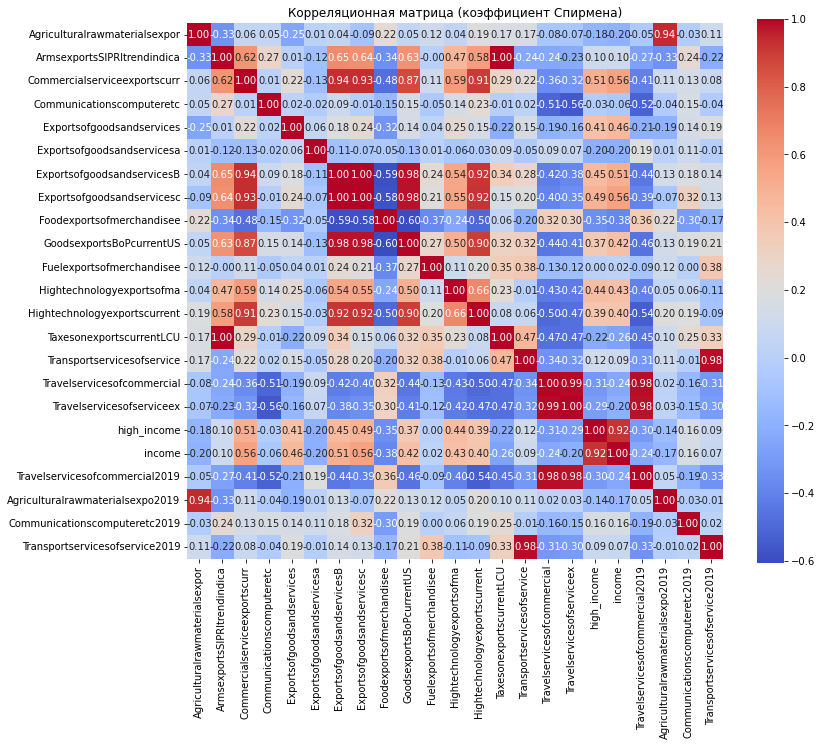

In [87]:
# Вычисление корреляционной матрицы (коэффициент Спирмена)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Визуализация корреляционной матрицы с помощью тепловой карты
plt.figure(figsize=(12, 10))  # Размер графика
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Корреляционная матрица (коэффициент Спирмена)")
plt.show()
#для визуального упрощения и удобства использования было решено использовать тип матрицы хитмэп

Из всех корреляций переменных самой необоснованной, на наш взгляд, является корреляция между переменными ArmsexportsSIPRItrendindica и TaxesonexportscurrentLCU и составляет 0.999757. Нелогичность такой высокой корреляции заметна в двух разрезах: формальном и смысловом. На формальном уровне странность заключается в том, что обе велчины измеряются в принципиально разных единицах: TaxesonexportscurrentLCU в долларах (= local currency unit) и ArmsexportsSIPRItrendindica, которая сама по себе является индексом и поэтому измеряется в себе самой, основываясь на количестве международных передач стандартных видов вооружения. На сайте Стокгольмского института исследования проблем мира - Stockholm International Peace Research Institute, SIPRI отдельно указано, что показатель не отражает стоимость поставленного оружия, и его некорректно сравнивать в метриками, имеющими отношение к деньгам типа ВВП. Экономически же откровенно трудно представить, чтобы налоги, собираемые только с экспорта США настолько сильно влияли на передачу оружия в мировом масштабе. Было бы возможно проследить тенденцию и объяснить зависимость, если бы, например, за показатели были бы взяты все (кумулятивные) налоги США и индекс СИПРИ только для Соединенных Штатов.

In [89]:
df = pd.read_excel('Worldbank.xlsx') 
# еще раз прочитаем файл, так как часто выдает ошибку и вместо p-value выдает значение nan

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CountryName                       217 non-null    object 
 1   CountryCode                       217 non-null    object 
 2   Agriculturalrawmaterialsexpor     126 non-null    float64
 3   ArmsexportsSIPRItrendindica       40 non-null     float64
 4   Commercialserviceexportscurr      164 non-null    float64
 5   Communicationscomputeretc         159 non-null    float64
 6   Exportsofgoodsandservices         168 non-null    float64
 7   Exportsofgoodsandservicesa        151 non-null    float64
 8   ExportsofgoodsandservicesB        163 non-null    float64
 9   Exportsofgoodsandservicesc        148 non-null    float64
 10  Foodexportsofmerchandisee         127 non-null    float64
 11  GoodsexportsBoPcurrentUS          164 non-null    float64
 12  Fuelexpo

In [91]:
df_dr = df.dropna(subset=['ArmsexportsSIPRItrendindica', 'TaxesonexportscurrentLCU'])

In [92]:
stats.pearsonr(df_dr['ArmsexportsSIPRItrendindica'], df_dr['TaxesonexportscurrentLCU'])

PearsonRResult(statistic=0.9997571382040694, pvalue=0.014030834817136274)

Заметна сильная парная корреляция (близка к 1), прямая зависимость. Корреляция статистически значима, так как значение p-value ниже уровня значимости 0,05.

Теперь проконтролируем влияние на эту корреляцию переменной ExportsofgoodsandservicesB - Exports of goods and services (BoP, current US dollars)

In [94]:
df = pd.read_excel('Worldbank.xlsx')
df_p = df.dropna(subset=['ArmsexportsSIPRItrendindica', 'TaxesonexportscurrentLCU', 'ExportsofgoodsandservicesB'])
r_xy = stats.pearsonr(df_p['ArmsexportsSIPRItrendindica'], df_p['TaxesonexportscurrentLCU'])[0]
r_xz = stats.pearsonr(df_p['ArmsexportsSIPRItrendindica'], df_p['ExportsofgoodsandservicesB'])[0]
r_yz = stats.pearsonr(df_p['TaxesonexportscurrentLCU'], df_p['ExportsofgoodsandservicesB'])[0]
r_xy_z = (r_xy - r_xz * r_yz) / sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))
print('Парный коэффициент корреляции между  TaxesonexportscurrentLCU и ArmsexportsSIPRItrendindica: ',r_xy)
print('Частный коэффициент корреляции между  TaxesonexportscurrentLCU и ArmsexportsSIPRItrendindica, с исключением влияния ExportsofgoodsandservicesB: ',r_xy_z)

Парный коэффициент корреляции между  TaxesonexportscurrentLCU и ArmsexportsSIPRItrendindica:  0.9997571382040694
Частный коэффициент корреляции между  TaxesonexportscurrentLCU и ArmsexportsSIPRItrendindica, с исключением влияния ExportsofgoodsandservicesB:  1.0000000000000007


Можно сделать вывод, что корреляция между налогами с экспорта и индекса СИПРИ увеличилась после исключения влияния кумулятивной стоимости экспорта товаров и услуг.

Тем не менее, мы понимаем, что странно, что значение частной корреляции (как и парной) не может быть больше 1.

In [95]:
corr, p_value = spearmanr(df['TaxesonexportscurrentLCU'], df['ArmsexportsSIPRItrendindica'])
print(f"Коэффициент корреляции Спирмена: {corr}, p-value: {p_value}")

Коэффициент корреляции Спирмена: nan, p-value: nan


In [97]:
df = pd.read_excel('Worldbank.xlsx')

In [98]:
df = df.dropna(subset=['ArmsexportsSIPRItrendindica', 'TaxesonexportscurrentLCU', 'ExportsofgoodsandservicesB'])

In [99]:
pg.partial_corr(data=df, x='TaxesonexportscurrentLCU', y='ArmsexportsSIPRItrendindica', covar='ExportsofgoodsandservicesB', method = 'spearman')
# проверка результата с помощью библиотеки penguin

,n,r,CI95%,p-val
spearman,3,-1.0,"[nan, nan]",NaN


Расчет частной корреляции коэффициентом Спирмена показал немного странные результаты. Возможно, такой результат получился из-за большой разницы в количестве наблюдений в выборке. А именно разницы между количеством значений по переменным ArmsexportsSIPRItrendindica и TaxesonexportscurrentLCU, с одной стороны, и ExportsofgoodsandservicesB, с другой. Потому что в результате применениния функции df.dropna(subset= ...) происходит снижение количества значений до 3. Тем не менее, здесь применили 2 метода расчета корреляции.

In [100]:
df.info() #расчет количество ненулевых значений по каждой переменной

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 147 to 203
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CountryName                       3 non-null      object 
 1   CountryCode                       3 non-null      object 
 2   Agriculturalrawmaterialsexpor     3 non-null      float64
 3   ArmsexportsSIPRItrendindica       3 non-null      float64
 4   Commercialserviceexportscurr      3 non-null      float64
 5   Communicationscomputeretc         3 non-null      float64
 6   Exportsofgoodsandservices         3 non-null      float64
 7   Exportsofgoodsandservicesa        3 non-null      float64
 8   ExportsofgoodsandservicesB        3 non-null      float64
 9   Exportsofgoodsandservicesc        3 non-null      float64
 10  Foodexportsofmerchandisee         3 non-null      float64
 11  GoodsexportsBoPcurrentUS          3 non-null      float64
 12  Fuelexportsof

Проверим 2 пару переменных. По обеим матрицам корреляции можно заметить высокие коэффициенты парной корреляции между переменными Hightechnologyexportscurrent и Commercialserviceexportscurr. Из задания 5 сделали вывод, что метрическая переменная Commercialserviceexportscurr статистически значимо отличается от нормального распределения. В задании 1 на нормальность была проверена переменная Hightechnologyexportscurrent, которая также не имеет нормального распределения. Поэтому для оценки корреляции был использован коэффициент Спирмена.

In [101]:
df = pd.read_excel('Worldbank.xlsx')

In [102]:
df_drp = df.dropna(subset=['Hightechnologyexportscurrent', 'Commercialserviceexportscurr'])

In [103]:
corr, p_value = spearmanr(df_drp['Hightechnologyexportscurrent'], df_drp['Commercialserviceexportscurr'])
print(f"Коэффициент корреляции Спирмена: {corr}, p-value: {p_value}") #парная корреляция

Коэффициент корреляции Спирмена: 0.9055329062317996, p-value: 1.2088834273295214e-38


Заметна сильная парная корреляция (близка к 1), прямая зависимость. Корреляция статистически значима, так как значение p-value ниже уровня значимости 0,05.

Теперь проконтролируем влияние на эту корреляцию переменной ExportsofgoodsandservicesB.

In [104]:
df2 = df.dropna(subset=['Hightechnologyexportscurrent', 'Commercialserviceexportscurr', 'ExportsofgoodsandservicesB'])

In [105]:
pg.partial_corr(data=df2, x='Hightechnologyexportscurrent', y='Commercialserviceexportscurr', covar='ExportsofgoodsandservicesB', method = 'spearman')

,n,r,CI95%,p-val
spearman,101,0.277296,"[0.09, 0.45]",0.005221


Можно сделать вывод, что корреляция между экспортом высокотехнологичной продукции и экспортом коммерческих услуг сократилась после исключения влияния переменной объема экспорта товаров и услуг. Корреляция стала слабой, но по-прежнему остается статистически значимой.

### 5. Сравнение средних

Проанализируйте распределение значений двух переменных:
- Communications, computer, etc. (% of service imports, BoP);
- Transport services (% of service exports, BoP).

Выберите и проведите подходящий статистический тест для проверки того, различаются ли значения каждой переменной по следующий группам:
- Высокодоходные и другие страны (переменная high_income)
- Страны, относящиеся к различным группам по доходу: высокий, средний, низкий (переменная income);
- Развитые и развивающиеся страны (переменная development).

Выберите и проведите подходящий статистический тест для проверки того, различаются ли значения каждой переменной за 2018 и 2019 годы.

Объясните выбор каждого статистического теста. Сформулируйте гипотезы. Интерпретируйте результаты анализа. Визуализируйте наблюдаемые тенденции на подходящих графиках.

1. **Анализ распределения переменных**

Communications, computer, etc. (% of service imports, BoP) - **переменная Communicationscomputeretc**

H0: Распределение переменной процент экспорта ИКТ услуг от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта ИКТ услуг от экспорта всех услуг отличается от нормального.

<Axes: xlabel='Communicationscomputeretc', ylabel='Density'>

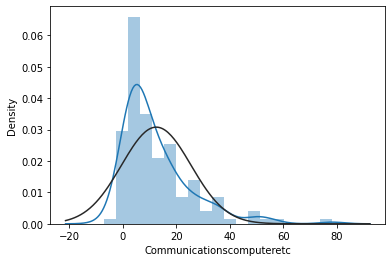

In [106]:
sns.distplot(df.Communicationscomputeretc.dropna(),  fit=norm)

In [107]:
df['Communicationscomputeretc'].dropna().count()

159

По виду гистограммы, по итогу сравнения распределения переменной с нормальным, можно сделать вывод, что распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия. Теперь проведем тест Колмогорова-Смирнова (так как значений больше 50).

In [108]:
stats.kstest(df['Communicationscomputeretc'].dropna(), 'norm', args=(df['Communicationscomputeretc'].dropna().mean(), df['Communicationscomputeretc'].dropna().std()))

KstestResult(statistic=0.15621621814006426, pvalue=0.0007438419048175331, statistic_location=0.1063909193956534, statistic_sign=-1)

p-value < 0.05 (уровня значимости), значит гипотеза H0 отвергается, что говорит о том, что распределение переменной Communicationscomputeretc статистически значимо отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

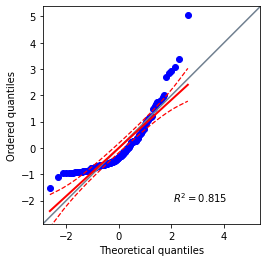

In [109]:
pg.qqplot(df['Communicationscomputeretc'], dist = 'norm')

Точки эмпирического распределения (исследуемой переменной) не выстроены вдоль красной прямой линии. График подтверждает, что распределение рассматриваемой переменной не может быть представлено линейной функцией. Коэффициент детерминации (R^2 = 0.815) довольно высокий, распределение приближено к нормальному, но тем не менее все еще не совпадает с нормальным.

Transport services (% of service exports, BoP) - **переменная Transportservicesofservice**

H0: Распределение переменной процент экспорта транспортных услуг от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта транспортных услуг от экспорта всех услуг отличается от нормального.

<Axes: xlabel='Transportservicesofservice', ylabel='Density'>

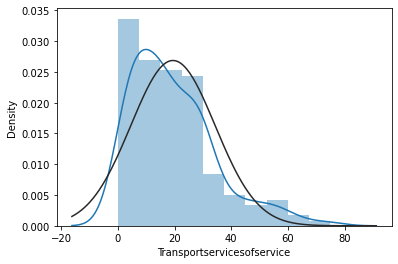

In [110]:
sns.distplot(df.Transportservicesofservice.dropna(),  fit=norm)

In [111]:
df['Transportservicesofservice'].dropna().count()

159

По виду гистограммы, по итогу сравнения распределения переменной с нормальным, можно сделать вывод, что распределение рассматриваемой переменной не является нормальным, наблюдается ассиметрия.

Проведем тест Колмогорова-Смирнова (так как значений больше 50).

In [112]:
stats.kstest(df['Transportservicesofservice'].dropna(), 'norm', args=(df['Transportservicesofservice'].dropna().mean(), df['Transportservicesofservice'].dropna().std()))

KstestResult(statistic=0.10491513638229732, pvalue=0.05607997953022392, statistic_location=17.025659002304316, statistic_sign=1)

p-value превысило уровень значимости 0.05, поэтому в данном случае гипотеза H0 принимается --> распределение переменной Transportservicesofservice статистически значимо не отличается от нормального распределения.

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

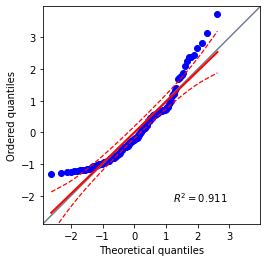

In [113]:
pg.qqplot(df['Transportservicesofservice'], dist = 'norm')

**2. Проверка того, различаются ли значения каждой переменной по группам.**

*Communicationscomputeretc по группам высокодоходные и другие страны (переменная high_income)*

Сначала рассмотрим основные описательные статистики переменной в зависимости от принадлежности к группе стран с высоким доходом или другим странам.

In [114]:
df = pd.read_excel('Worldbank.xlsx')

In [115]:
df.pivot_table(index='high_income', values=['Communicationscomputeretc'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Communicationscomputeretc,Communicationscomputeretc
high_income,,
0,13.561,14.757
1,10.828,8.937


<Axes: xlabel='high_income'>

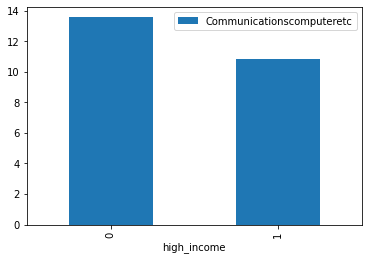

In [116]:
df.groupby('high_income')[['Communicationscomputeretc']].mean().plot(kind='bar')
#средние значения переменной по 2 группам

Перекодируем переменную high_income, чтобы построить error bar по данной переменной.

In [117]:
df['high_income_f']=df['high_income'].replace({1: 'yes', 0: 'no'})
#перекодируем и запишем новые значения в новый столбец

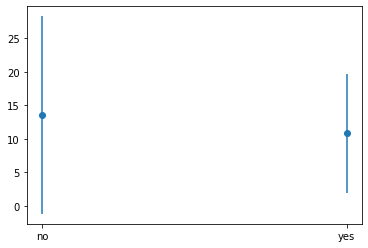

In [118]:
x = ['no', 'yes']
y = [df[df.high_income_f=='no']['Communicationscomputeretc'].mean(), df[df.high_income_f=='yes']['Communicationscomputeretc'].mean()]
e = [df[df.high_income_f=='no']['Communicationscomputeretc'].std(), df[df.high_income_f=='yes']['Communicationscomputeretc'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

In [119]:
df

,CountryName,CountryCode,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,...,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,development,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019,high_income_f
0,Afghanistan,AFG,17.113304,NaN,6.230657e+08,28.402324,NaN,NaN,1.611540e+09,NaN,...,4.482772,3.793358,0,low income,developing,14.367959,NaN,6.467647,16.344074,no
1,Albania,ALB,0.313849,NaN,3.574339e+09,16.058391,31.684671,3.196598,4.784712e+09,4.807222e+09,...,61.150507,60.361848,0,middle income,developing,62.216690,NaN,5.979548,7.154605,no
2,Algeria,DZA,NaN,NaN,NaN,NaN,25.623547,-4.300000,NaN,5.296803e+10,...,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN,no
3,American Samoa,ASM,NaN,NaN,NaN,NaN,68.867925,14.325843,NaN,3.321704e+08,...,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN,no
4,Andorra,AND,1.551347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,high income,developed,NaN,NaN,NaN,NaN,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,high income,developing,NaN,NaN,NaN,NaN,yes
213,West Bank and Gaza,PSE,NaN,NaN,5.608593e+08,36.257881,19.865352,7.878720,2.903485e+09,2.456322e+09,...,43.720375,40.034937,0,middle income,developing,45.238319,0.913553,10.780279,1.079660,no
214,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,low income,developing,NaN,0.017167,NaN,NaN,no
215,Zambia,ZMB,0.903647,NaN,9.532642e+08,3.739193,37.422550,NaN,9.982666e+09,NaN,...,77.857990,77.857990,0,middle income,developing,80.805321,1.332663,9.384435,4.395867,no


Общий вывод по итогам анализа описательных статистик: в среднем процент экспорта ИКТ услуг (от общего экспорта услуг) по группе стран, не располагающих высоким доходом, выше, чем по группе стран с высоким доходам. Столбчатая диаграмма еще раз наглядно это подтверждает.

Стандартное отклонение показывает разброс значений от среднего. В группе стран с высоким доходом значения не сильно отклоняются от среднего. Больше отклонение от среднего по группе другие страны.

In [120]:
df.groupby('high_income')[['Communicationscomputeretc']].count()

,Communicationscomputeretc
high_income,
0,102
1,57


Переменная Communicationscomputeretc является метрической переменной. Ее распределение статистически значимо отличается от нормального (проверено выше). Число наблюдений в каждой подгруппе различается. Следовательно, будем использовать аналогичные непараметрические тесты.

Рассматриваются 2 независимые выборки - по группе стран с высоким доходам и другим. Поэтому подходящий непараметрический тест - U-критерий Манна — Уитни.

Гипотезы:

H0: Значения переменной процент экспорта услуг ИКТ от экспорта всех товаров для стран с высоким доходом и других стран не отличаются.

H1: Значения переменной процент экспорта услуг ИКТ от экспорта всех товаров для стран с высоким доходом и других стран отличаются.

In [121]:
group0 = df[df['high_income']==0]['Communicationscomputeretc']
group1 = df[df['high_income']==1]['Communicationscomputeretc']
stats.mannwhitneyu(group0.dropna(), group1.dropna())

MannwhitneyuResult(statistic=2995.0, pvalue=0.7533169455274005)

Значение p-value > 0.05, следовательно, гипотеза H1 отклоняется. Значения переменной **не отличаются** в зависимости от принадлежности к группе стран с высоким доходом и другим странам.

*Communicationscomputeretc по группам развитые и развивающиеся страны (переменная development)*

In [122]:
df.pivot_table(index='development', values=['Communicationscomputeretc'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Communicationscomputeretc,Communicationscomputeretc
development,,
developed,12.640,8.734
developing,12.562,14.154


<Axes: xlabel='development'>

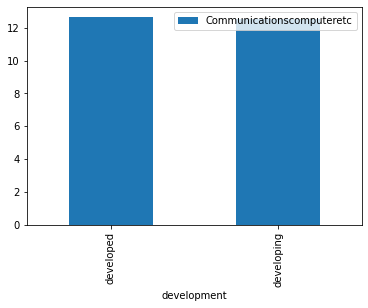

In [123]:
df.groupby('development')[['Communicationscomputeretc']].mean().plot(kind='bar')

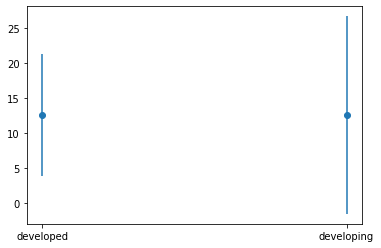

In [124]:
x = ['developed', 'developing']
y = [df[df.development=='developed']['Communicationscomputeretc'].mean(), df[df.development=='developing']['Communicationscomputeretc'].mean()]
e = [df[df.development=='developed']['Communicationscomputeretc'].std(), df[df.development=='developing']['Communicationscomputeretc'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Вывод: в среднем процент экспорта ИКТ услуг (от общего экспорта услуг) по группам развитых и развивающихся стран не отличаются, что отражено на столбчатой диаграмме.

В группе развитых стран значения доли экспорта ИКТ услуг демонстрируют меньший разброс от среднего значения. Среди развивающихся стран экспорт ИКТ услуг мог составлять как максимально высокий процент, так и полностью отсутствовать в структуре экспорта.

In [125]:
df.groupby('development')[['Communicationscomputeretc']].count()

,Communicationscomputeretc
development,
developed,39
developing,120


Как и в предыдущем случае, будем использовать непараметрический тест.

Рассматриваются 2 несвязанные выборки - по развитым и развивающимся странам. Поэтому снова был применен U-критерий Манна — Уитни.

Гипотезы:

H0: Значения переменной процент экспорта услуг ИКТ от экспорта всех товаров для развитых и развивающихся стран не отличаются.

H1: Значения переменной процент экспорта услуг ИКТ от экспорта всех товаров для развитых и развивающихся стран отличаются.

In [126]:
group0 = df[df['development']=='developing']['Communicationscomputeretc']
group1 = df[df['development']=='developed']['Communicationscomputeretc']
stats.mannwhitneyu(group0.dropna(), group1.dropna())

MannwhitneyuResult(statistic=1936.0, pvalue=0.10624731261879312)

Значение p-value > 0.05 (даже выше уровня значимости 1%). Гипотеза H1 отклоняется. Значения переменной не отличаются в зависимости от принадлежности к группе развитых или развивающихся стран.

*Communicationscomputeretc по уровню дохода (переменная income)*

In [127]:
df.pivot_table(index='income', values=['Communicationscomputeretc'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Communicationscomputeretc,Communicationscomputeretc
income,,
high income,10.828,8.937
low income,20.038,21.218
middle income,12.356,13.036


<Axes: xlabel='income'>

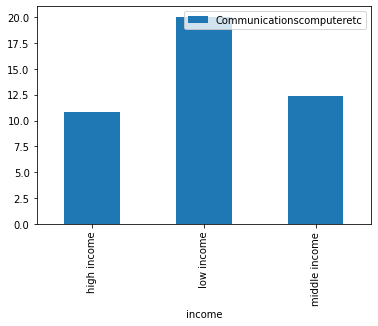

In [128]:
df.groupby('income')[['Communicationscomputeretc']].mean().plot(kind='bar')
#средние значения переменной по 3 группам

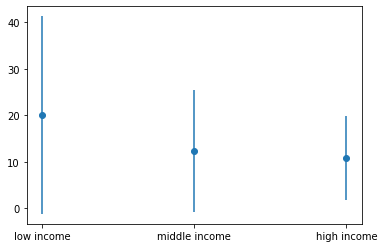

In [129]:
x = ['low income', 'middle income', 'high income']
y = [df[df.income=='low income']['Communicationscomputeretc'].mean(), df[df.income=='middle income']['Communicationscomputeretc'].mean(), df[df.income=='high income']['Communicationscomputeretc'].mean()]
e = [df[df.income=='low income']['Communicationscomputeretc'].std(), df[df.income=='middle income']['Communicationscomputeretc'].std(), df[df.income=='high income']['Communicationscomputeretc'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Вывод: если рассматривать переменную по более детализированным группам, соответствующим уровню дохода, можно отметить, что в среднем доля экспорта услуг ИКТ наибольшая в странах с низким благосостоянием, и наименьшая - в самых богатых странах.

Наибольший разброс значений переменной в странах с низким доходом, а наименьшее отклонение от среднего показателя - в государствах с высоким уровнем благосостояния.

In [130]:
df.groupby('income')[['Communicationscomputeretc']].count()

,Communicationscomputeretc
income,
high income,57
low income,16
middle income,86


Переменная Communicationscomputeretc является метрической переменной. Ее распределение статистически значимо отличается от нормального. Число наблюдений в каждой подгруппе различается. Следоввательно, будем использовать аналогичные непараметрические тесты.

Имеем дело с 3 независимыми выборками. Поэтому используем критерий Краскела-Уоллиса.

Гипотезы:

H0: Значения переменной процент экспорта ИКТ услуг от экспорта всех товаров для стран, относящихся к трём разным группам по уровню дохода, не отличаются.

H1: Значения переменной процент экспорта ИКТ услуг от экспорта всех товаров для стран, относящихся к трём разным группам по уровню дохода, отличаются.

In [131]:
df = df.dropna(subset=['Communicationscomputeretc'])
group_high = df[df['income']=='high income']['Communicationscomputeretc']
group_low = df[df['income']=='low income']['Communicationscomputeretc']
group_middle = df[df['income']=='middle income']['Communicationscomputeretc']

In [132]:
stats.kruskal(group_high, group_low, group_middle)

KruskalResult(statistic=1.6743167498055982, pvalue=0.4329390275345668)

Значение p-value > 0.05, следовательно, гипотеза H1 отклоняется. Значения переменной для стран, относящихся к трём разным группам по уровню дохода, **не отличаются**.

*Transportservicesofservice по группам высокодоходные и другие страны (переменная high_income)*

In [133]:
df.pivot_table(index='high_income', values=['Transportservicesofservice'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Transportservicesofservice,Transportservicesofservice
high_income,,
0,17.701,14.098
1,21.102,15.001


<Axes: xlabel='high_income'>

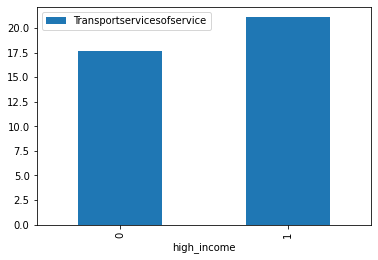

In [134]:
df.groupby('high_income')[['Transportservicesofservice']].mean().plot(kind='bar')

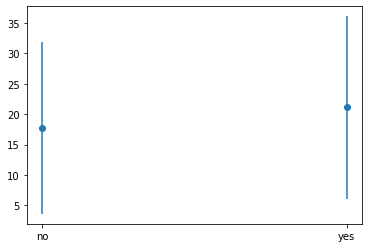

In [135]:
x = ['no', 'yes']
y = [df[df.high_income_f=='no']['Transportservicesofservice'].mean(), df[df.high_income_f=='yes']['Transportservicesofservice'].mean()]
e = [df[df.high_income_f=='no']['Transportservicesofservice'].std(), df[df.high_income_f=='yes']['Transportservicesofservice'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Вывод по итогам анализа описательных статистик: в среднем процент транспортных услуг в общей структуре экспорта услуг выше в группе развитых стран. Но разница в средних значениях не настолько велика.

Больший разброс значений от среднего наблюдается в группе стран с высоким доходом, хотя значения стандартного отклонения почти равны.

Transportservicesofservice статистически значимо не отличается от нормального распределения. Переменная метрическая. Поэтому можно провести параметрический тест.

Есть 2 независимые выборки - по группе стран с высоким доходам и другим. Поэтому подходящий параметрический тест - t-тест для двух независимых выборок.

Гипотезы:

H0: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для стран с высоким доходом и других стран не отличаются.

H1: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для стран с высоким доходом и других стран отличаются.

In [136]:
group0 = df[df['high_income']==0]['Transportservicesofservice']
group1 = df[df['high_income']==1]['Transportservicesofservice']

In [137]:
stats.ttest_ind(group0.dropna(), group1.dropna())

Ttest_indResult(statistic=-1.4124113982317532, pvalue=0.159846510846963)

p-value > 0.05, значит гипотеза H0 принимается, средние значения переменной по 2 группам **не отличаются**.

*Transportservicesofservice по группам развитые и развивающиеся страны (переменная development)*

In [138]:
df.pivot_table(index='development', values=['Transportservicesofservice'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Transportservicesofservice,Transportservicesofservice
development,,
developed,20.881,13.596
developing,18.269,14.752


<Axes: xlabel='development'>

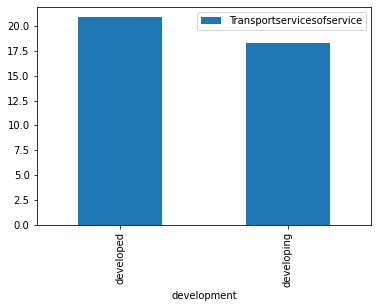

In [139]:
df.groupby('development')[['Transportservicesofservice']].mean().plot(kind='bar')

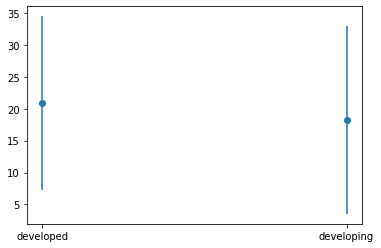

In [140]:
x = ['developed', 'developing']
y = [df[df.development=='developed']['Transportservicesofservice'].mean(), df[df.development=='developing']['Transportservicesofservice'].mean()]
e = [df[df.development=='developed']['Transportservicesofservice'].std(), df[df.development=='developing']['Transportservicesofservice'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Вывод по итогам анализа описательных статистик: в среднем процент экспортируемых траспортных услуг в общей структуре экспорта услуг выше в странах с развитой экономикой, но нельзя сказать, что наблюдается значительная разница.

Обращая внимание на значение стандартного отклонения, можно сделать вывод, что больший разброс значений от среднего в группе развивающихся стран.

2 независимые выборки - по группе развитых и развивающихся стран. Поэтому подходящий параметрический тест - t-тест для двух независимых выборок.

Гипотезы:

H0: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для развитых и развивающихся стран не отличаются.

H1: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для развитых и развивающихся стран отличаются.

In [141]:
group0 = df[df['development']=='developing']['Transportservicesofservice']
group1 = df[df['development']=='developed']['Transportservicesofservice']

In [142]:
stats.ttest_ind(group0.dropna(), group1.dropna())

Ttest_indResult(statistic=-0.9759883922822785, pvalue=0.3306008382080483)

p-value > 0.05, значит гипотеза H0 принимается, средние значения переменной по 2 группам **не отличаются**.

*Transportservicesofservice по уровню дохода (переменная income)*

In [143]:
df.pivot_table(index='income', values=['Transportservicesofservice'], aggfunc=['mean', 'std']).round(3)

,mean,std
,Transportservicesofservice,Transportservicesofservice
income,,
high income,21.102,15.001
low income,22.026,22.542
middle income,16.997,12.255


<Axes: xlabel='income'>

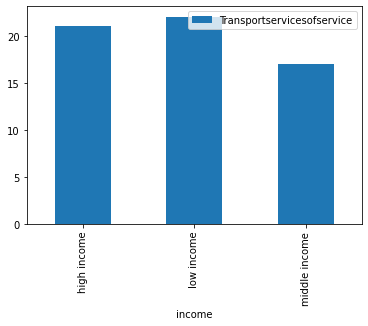

In [144]:
df.groupby('income')[['Transportservicesofservice']].mean().plot(kind='bar')

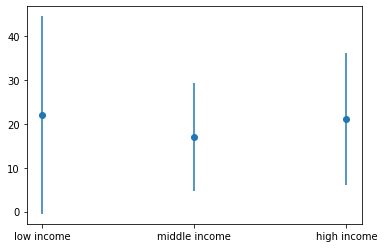

In [145]:
x = ['low income', 'middle income', 'high income']
y = [df[df.income=='low income']['Transportservicesofservice'].mean(), df[df.income=='middle income']['Transportservicesofservice'].mean(), df[df.income=='high income']['Transportservicesofservice'].mean()]
e = [df[df.income=='low income']['Transportservicesofservice'].std(), df[df.income=='middle income']['Transportservicesofservice'].std(), df[df.income=='high income']['Transportservicesofservice'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Вывод на основе анализа описательных статистик: в среднем процент экспорта транспортных услуг в общем экспорте услуг наиболее высокий в странах с низким уровнем дохода, наименьший - в странах со средним благосостоянием. НО также в бедных государствах можно отметить и наиболее значительный разброс значений от среднего. В категории стран со средним доходом этот разброс наименьший.

Имеем дело с 3 независимыми выборками - группы по уровню дохода. Переменная Transportservicesofservice метрическая и статистически значимо не отличается от нормального распределение. Поэтому был использован параметрический тест ANOVA.

Гипотезы:

H0: Cредние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для стран, относящихся к трём разным группам по уровню дохода, не отличаются.

H1: Cредние значения переменной процент экспорта транспортных услуг от экспорта всех услуг для стран, относящихся к трём разным группам по уровню дохода, отличаются.

In [146]:
df = df.dropna(subset=['Transportservicesofservice'])
group_high = df[df['income']=='high income']['Transportservicesofservice']
group_low = df[df['income']=='low income']['Transportservicesofservice']
group_middle = df[df['income']=='middle income']['Transportservicesofservice']

In [147]:
stats.f_oneway(group_high, group_low, group_middle)

F_onewayResult(statistic=1.7342862930659153, pvalue=0.1799781270079979)

p-value > 0.05, значит гипотеза H0 принимается, средние значения переменной по 3 группам не отличаются. В этой ситуации ввиду отсутствия разницы в средних значениях, нет смысла проводить апостериорный тест и сравнивать группы попарно.

**3. Проверка того, различаются ли значения каждой переменной за 2018 и 2019 годы**

*Travelservicesofcommercial2019 и
Travelservicesofcommercial*

<Axes: xlabel='Travelservicesofcommercial', ylabel='Density'>

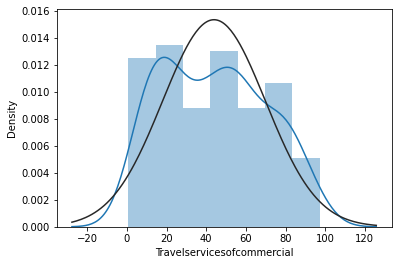

In [148]:
sns.distplot(df.Travelservicesofcommercial.dropna(), fit=stats.norm)

Проведем тест Колмогорова-Смирнова для проверки нормальности распределения переменных.

Гипотеза:

H0: Распределение переменной процент экспорта туристических услуг от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта туристических услуг от экспорта всех услуг отличается от нормального.

In [149]:
stats.kstest(df.Travelservicesofcommercial.dropna(), 'norm', args=(df.Travelservicesofcommercial.mean(), df.Travelservicesofcommercial.std()))

KstestResult(statistic=0.10516335771953872, pvalue=0.058938130180235415, statistic_location=26.643863583617026, statistic_sign=1)

p-value > 0.05, гипотеза H1 отклоняется, а H0 не отклоняется. Распределение переменной статистически значимо не отличается от нормального.

<Axes: xlabel='Travelservicesofcommercial2019', ylabel='Density'>

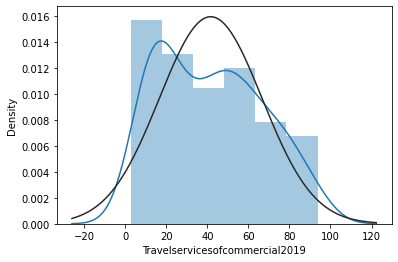

In [150]:
sns.distplot(df.Travelservicesofcommercial2019.dropna(), fit=stats.norm)

Гипотеза:

H0: Распределение переменной процент экспорта туристических услуг в 2019 от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта туристических услуг в 2019 от экспорта всех услуг отличается от нормального.

In [151]:
stats.kstest(df.Travelservicesofcommercial2019.dropna(), 'norm', args=(df.Travelservicesofcommercial2019.mean(), df.Travelservicesofcommercial2019.std()))

KstestResult(statistic=0.11207399134026835, pvalue=0.07805140084010147, statistic_location=24.279977798461914, statistic_sign=1)

p-value > 0.05, гипотеза H1 отклоняется, а H0 не отклоняется. Распределение переменной статистически значимо не отличается от нормального.

Обе переменные имеют метрическую шкалу, и их распределения не отличаются от нормального. Для проверки на наличие различий в значениях будет использован параметрический тест.

В случае с данными переменными, выборки являются связанными: сравниваются переменные, измеряющие один и тот же показатель. Используем T-test для двух связанных выборок.


Гипотезы:

H0: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг в 2018 и в 2019 годах не отличаются.

H1: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг в 2018 и в 2019 годах отличаются.

In [152]:
df = df.dropna(subset=['Travelservicesofcommercial'])
df = df.dropna(subset=['Travelservicesofcommercial2019'])
stats.ttest_rel(df['Travelservicesofcommercial2019'], df['Travelservicesofcommercial'])

TtestResult(statistic=0.8994914385206966, pvalue=0.37012049062777796, df=125)

После проведения теста получили значение p-value > 0.05. Следовательно, гипотеза H0 не отвергается. Средние значения переменных **не отличаются**.



---


*Agriculturalrawmaterialsexpo2019 и Agriculturalrawmaterialsexpor*

Проверим рассматриваемые переменные на соответствие нормальному распределению. Проведем тест Колмогорова-Смирнова.

<Axes: xlabel='Agriculturalrawmaterialsexpo2019', ylabel='Density'>

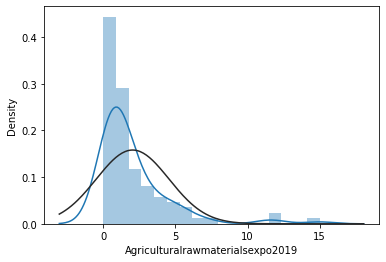

In [153]:
sns.distplot(df.Agriculturalrawmaterialsexpo2019.dropna(), fit=stats.norm)

H0: Распределение переменной процент экспорта сельскохозяйственного сырья в 2019 от экспорта всех товаров не отличается от нормального.

H1: Распределение переменной процент экспорта сельскохозяйственного сырья в 2019 от экспорта всех товаров отличается от нормального.


In [154]:
stats.kstest(df.Agriculturalrawmaterialsexpo2019.dropna(), 'norm', args=(df.Agriculturalrawmaterialsexpo2019.mean(), df.Agriculturalrawmaterialsexpo2019.std()))

KstestResult(statistic=0.21116287645143844, pvalue=0.000283771761396335, statistic_location=0.0, statistic_sign=-1)

In [155]:
print(1.0454902400581402e-12 < 0.05)

True


p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Распределение переменной Agriculturalrawmaterialsexpo2019 отличается от нормального.

Agriculturalrawmaterialsexpor

H0: Распределение переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров не отличается от нормального.

H1: Распределение переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров отличается от нормального.

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Density'>

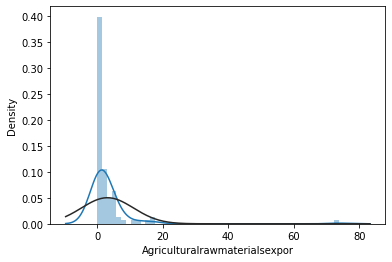

In [156]:
sns.distplot(df.Agriculturalrawmaterialsexpor.dropna(), fit=stats.norm)

In [157]:
stats.kstest(df.Agriculturalrawmaterialsexpor.dropna(), 'norm', args=(df.Agriculturalrawmaterialsexpor.mean(), df.Agriculturalrawmaterialsexpor.std()))

KstestResult(statistic=0.346333240742676, pvalue=6.727411407192218e-11, statistic_location=0.0020306141439364964, statistic_sign=-1)

In [158]:
print(3.924587324163506e-14 < 0.05)

True


p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Распределение переменной Agriculturalrawmaterialsexpor отличается от нормального.

Обе переменные имеют метрическую шкалу, их распределения отличаются от нормального. Для проверки на наличие различий в значениях будет использован непараметрический тест.

Выборки являются связанными: сравниваются переменные, измеряющие один и тот же показатель. Используем Wilcoxon signed-rank test.

Гипотезы:

H0: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров в 2018 и в 2019 годах не отличаются.

H1: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров в 2018 и в 2019 годах отличаются.

In [159]:
df = df.dropna(subset=['Agriculturalrawmaterialsexpor'])
df = df.dropna(subset=['Agriculturalrawmaterialsexpo2019'])
stats.wilcoxon(df['Agriculturalrawmaterialsexpor'], df['Agriculturalrawmaterialsexpo2019'])

WilcoxonResult(statistic=1400.0, pvalue=0.029596543451034813)

p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Значения переменной в 2018 и 2019 гг. **отличаются**.



---


*Communicationscomputeretc2019 и Communicationscomputeretc*

Проведем тест Колмогорова-Смирнова для обеих переменных.

Communicationscomputeretc

H0: Распределение переменной процент экспорта услуг ИКТ от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта услуг ИКТ от экспорта всех услуг отличается от нормального.

<Axes: xlabel='Communicationscomputeretc', ylabel='Density'>

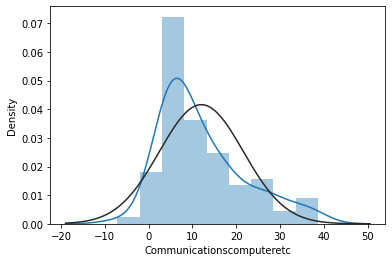

In [160]:
sns.distplot(df.Communicationscomputeretc.dropna(), fit=stats.norm)

In [161]:
stats.kstest(df.Communicationscomputeretc.dropna(), 'norm', args=(df.Communicationscomputeretc.mean(), df.Communicationscomputeretc.std()))

KstestResult(statistic=0.14038544217976312, pvalue=0.05863364133647155, statistic_location=11.869184488348699, statistic_sign=1)

p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Распределение переменной Communicationscomputeretc отличается от нормального.

Communicationscomputeretc2019

H0: Распределение переменной процент экспорта услуг ИКТ в 2019 от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта услуг ИКТ в 2019 от экспорта всех услуг отличается от нормального.

In [162]:
stats.kstest(df.Communicationscomputeretc2019.dropna(), 'norm', args=(df.Communicationscomputeretc2019.mean(), df.Communicationscomputeretc2019.std()))

KstestResult(statistic=0.11309425655259531, pvalue=0.19997931055075271, statistic_location=12.521490097045898, statistic_sign=1)

p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Распределение переменной Communicationscomputeretc2019 отличается от нормального.

Обе переменные имеют метрическую шкалу, и их распределения отличаются от нормального. Для проверки на наличие различий в значениях будет использован непараметрический тест.

Выборки являются связанными: сравниваются переменные, измеряющие один и тот же показатель. Используем Wilcoxon signed-rank test.

Гипотеза:

H0: Значения переменной процент экспорта услуг ИКТ от экспорта всех услуг в 2018 и в 2019 годах не отличаются.

H1: Значения переменной процент экспорта услуг ИКТ от экспорта всех услуг в 2018 и в 2019 годах отличаются.

In [163]:
df = df.dropna(subset=['Communicationscomputeretc2019'])
df = df.dropna(subset=['Communicationscomputeretc'])
stats.wilcoxon(df['Communicationscomputeretc'], df['Communicationscomputeretc2019'])

WilcoxonResult(statistic=1770.0, pvalue=0.5422168639953012)

После проведения теста получили значение p-value > 0.05. Следовательно, гипотеза H0 не отвергается. Значения переменных **не отличаются**.



---


*Transportservicesofservice2019 и Transportservicesofservice*

Проведем тест Колмогорова-Смирнова для обеих переменных.

Transportservicesofservice2019

H0: Распределение переменной процент экспорта транспортных услуг в 2019 от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта транспортных услуг в 2019 от экспорта всех услуг отличается от нормального.

In [164]:
stats.kstest(df.Transportservicesofservice2019.dropna(), 'norm', args=(df.Transportservicesofservice2019.mean(), df.Transportservicesofservice2019.std()))

KstestResult(statistic=0.10251496449755199, pvalue=0.2991610955145807, statistic_location=16.20166778564453, statistic_sign=1)

Transportservicesofservice

H0: Распределение переменной процент экспорта транспортных услуг от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта транспортных услуг от экспорта всех услуг отличается от нормального.

In [165]:
stats.kstest(df.Transportservicesofservice.dropna(), 'norm', args=(df.Transportservicesofservice.mean(), df.Transportservicesofservice.std()))

KstestResult(statistic=0.10206882654246607, pvalue=0.3040016244168103, statistic_location=17.025659002304316, statistic_sign=1)

В обоих случаях значение p-value > 0.05, гипотеза H1 отклоняется, а H0 не отклоняется. Распределения переменных статистически значимо не отличаются от нормального.

Обе переменные имеют метрическую шкалу, и их распределения не отличаются от нормального. Для проверки на наличие различий в значениях будет использован параметрический тест.

В случае с данными переменными, выборки являются связанными: сравниваются переменные, измеряющие один и тот же показатель. Используем T-test для двух связанных выборок.

Гипотезы:

H0: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг в 2018 и в 2019 годах не отличаются.

H1: Средние значения переменной процент экспорта транспортных услуг от экспорта всех услуг в 2018 и в 2019 годах отличаются.

In [166]:
df = df.dropna(subset=['Transportservicesofservice'])
df = df.dropna(subset=['Transportservicesofservice2019'])
stats.ttest_rel(df['Transportservicesofservice2019'], df['Transportservicesofservice'])

TtestResult(statistic=-2.3638230079213893, pvalue=0.020340676029435362, df=86)

p-value < 0.05, гипотеза H0 отклоняется, а H1 не отклоняется. Значения переменной в 2018 и 2019 гг. **отличаются**.